# Model Evaluation Notebook

This notebook evaluates the best models from all successful MLflow runs. It uses the `best.pt` weights and the test set defined in the training configuration.

## Evaluated Metrics
- mAP50
- mAP50-95
- Confusion Matrix

In [1]:
import mlflow
import os
from ultralytics import YOLO
import pandas as pd
import torch
from IPython.display import display, Image

In [2]:
# --- Check CUDA ---
import torch
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'Device count: {torch.cuda.device_count()}')
    print(f'Current device: {torch.cuda.current_device()}')
    print(f'Device name: {torch.cuda.get_device_name(0)}')
else:
    print('CUDA not available. Using CPU.')


CUDA available: True
Device count: 1
Current device: 0
Device name: NVIDIA GeForce RTX 4070 Laptop GPU


In [3]:
# --- Configuration ---
mlruns_dir = "mlruns"
db_path = "mlflow.db"
tracking_uri = f"sqlite:///{db_path}"

# Set MLflow Tracking URI
mlflow.set_tracking_uri(tracking_uri)
print(f"Tracking URI: {mlflow.get_tracking_uri()}")

Tracking URI: sqlite:///mlflow.db


In [4]:
# --- Find Best Models ---

# Search for all runs in the experiment
experiment_name = "Gun_Detection_Experiment"
experiment = mlflow.get_experiment_by_name(experiment_name)

if experiment is None:
    print(f"Experiment '{experiment_name}' not found.")
else:
    # Get all runs
    runs = mlflow.search_runs(experiment_ids=[experiment.experiment_id])
    
    # Filter for runs that have 'best.pt' in their artifacts
    evaluated_runs = []
    
    for _, run in runs.iterrows():
        run_id = run["run_id"]
        run_name = run["tags.mlflow.runName"]
        status = run["status"]
        
        if status != "FINISHED":
            continue
            
        # Construct path to best.pt
        # Based on exploration: mlruns/<run_id>/artifacts/weights/best.pt
        # Note: MLflow artifacts can be stored in various ways, but we verified the local structure
        artifact_uri = run["artifact_uri"]
        
# Convert URI to local path if necessary
        if artifact_uri.startswith("file:"):
             artifact_path = mlflow.utils.file_utils.local_file_uri_to_path(artifact_uri)
        else:
             # Fallback logic for relative paths in our specific setup
             artifact_path = os.path.join(mlruns_dir, run_id, "artifacts")
        
        # Prioritize local mlruns if it exists to override potential absolute paths from DB
        local_artifact_path = os.path.abspath(os.path.join(mlruns_dir, run_id, "artifacts"))
        if os.path.exists(local_artifact_path):
            artifact_path = local_artifact_path
        
        weights_path = os.path.join(artifact_path, "weights", "best.pt")
        
        if os.path.exists(weights_path):
            # Get Data Config
            # Retrieve parameters logged during training
            # The 'data' param is what we need
            data_config = run.get("params.data")
            
            if data_config:
                evaluated_runs.append({
                    "run_id": run_id,
                    "run_name": run_name,
                    "weights": weights_path,
                    "data": data_config
                })

    print(f"Found {len(evaluated_runs)} runs with valid 'best.pt' and data config.")
    display(pd.DataFrame(evaluated_runs))


2026/02/20 09:18:39 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.schemas
2026/02/20 09:18:39 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.tables
2026/02/20 09:18:39 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.types
2026/02/20 09:18:39 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.constraints
2026/02/20 09:18:39 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.defaults
2026/02/20 09:18:39 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.comments
2026/02/20 09:18:39 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/02/20 09:18:39 INFO alembic.runtime.migration: Will assume non-transactional DDL.


Found 5 runs with valid 'best.pt' and data config.


,run_id,run_name,weights,data
0,94a5fa9b3c5e4fb39db3988aaef884d8,gun_detection_run_real_syn_v3,d:\_pribadi\gun_detection\mlruns\94a5fa9b3c5e4...,data/data_real_syn_v3.yaml
1,704ef9d9174346c9a8f0df646618e41a,gun_detection_run_syn_v3,d:\_pribadi\gun_detection\mlruns\704ef9d917434...,data/data_syn_v3.yaml
2,487afaeed6c44b2eb161d947a0398e6e,gun_detection_run_real_syn_v2,d:\_pribadi\gun_detection\mlruns\487afaeed6c44...,data/data_real_syn_v2.yaml
3,6e83b006979b4033948822646f9901ea,gun_detection_run_syn_v2,d:\_pribadi\gun_detection\mlruns\6e83b006979b4...,data/data_syn_v2.yaml
4,3c9276e87d984ecfa08832c03b87408e,gun_detection_run_real,d:\_pribadi\gun_detection\mlruns\3c9276e87d984...,data/data_real.yaml



Evaluating Run: gun_detection_run_real_syn_v3 (94a5fa9b3c5e4fb39db3988aaef884d8)
Model Weights: d:\_pribadi\gun_detection\mlruns\94a5fa9b3c5e4fb39db3988aaef884d8\artifacts\weights\best.pt
Data Config: data/data_real_syn_v3.yaml

Ultralytics 8.4.12  Python-3.10.11 torch-2.10.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access  (ping: 0.30.1 ms, read: 226.693.0 MB/s, size: 94.4 KB)
val: Scanning D:\_pribadi\gun_detection\data\labels\test... 426 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 426/426 583.4it/s 0.7s0.1s
val: New cache created: D:\_pribadi\gun_detection\data\labels\test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 27/27 7.6it/s 3.5s0.2ss
                   all        426        431      0.993      0.991      0.995      0.953
Speed: 1.3ms preprocess, 3.4ms inference, 0.0ms loss, 0.2ms post

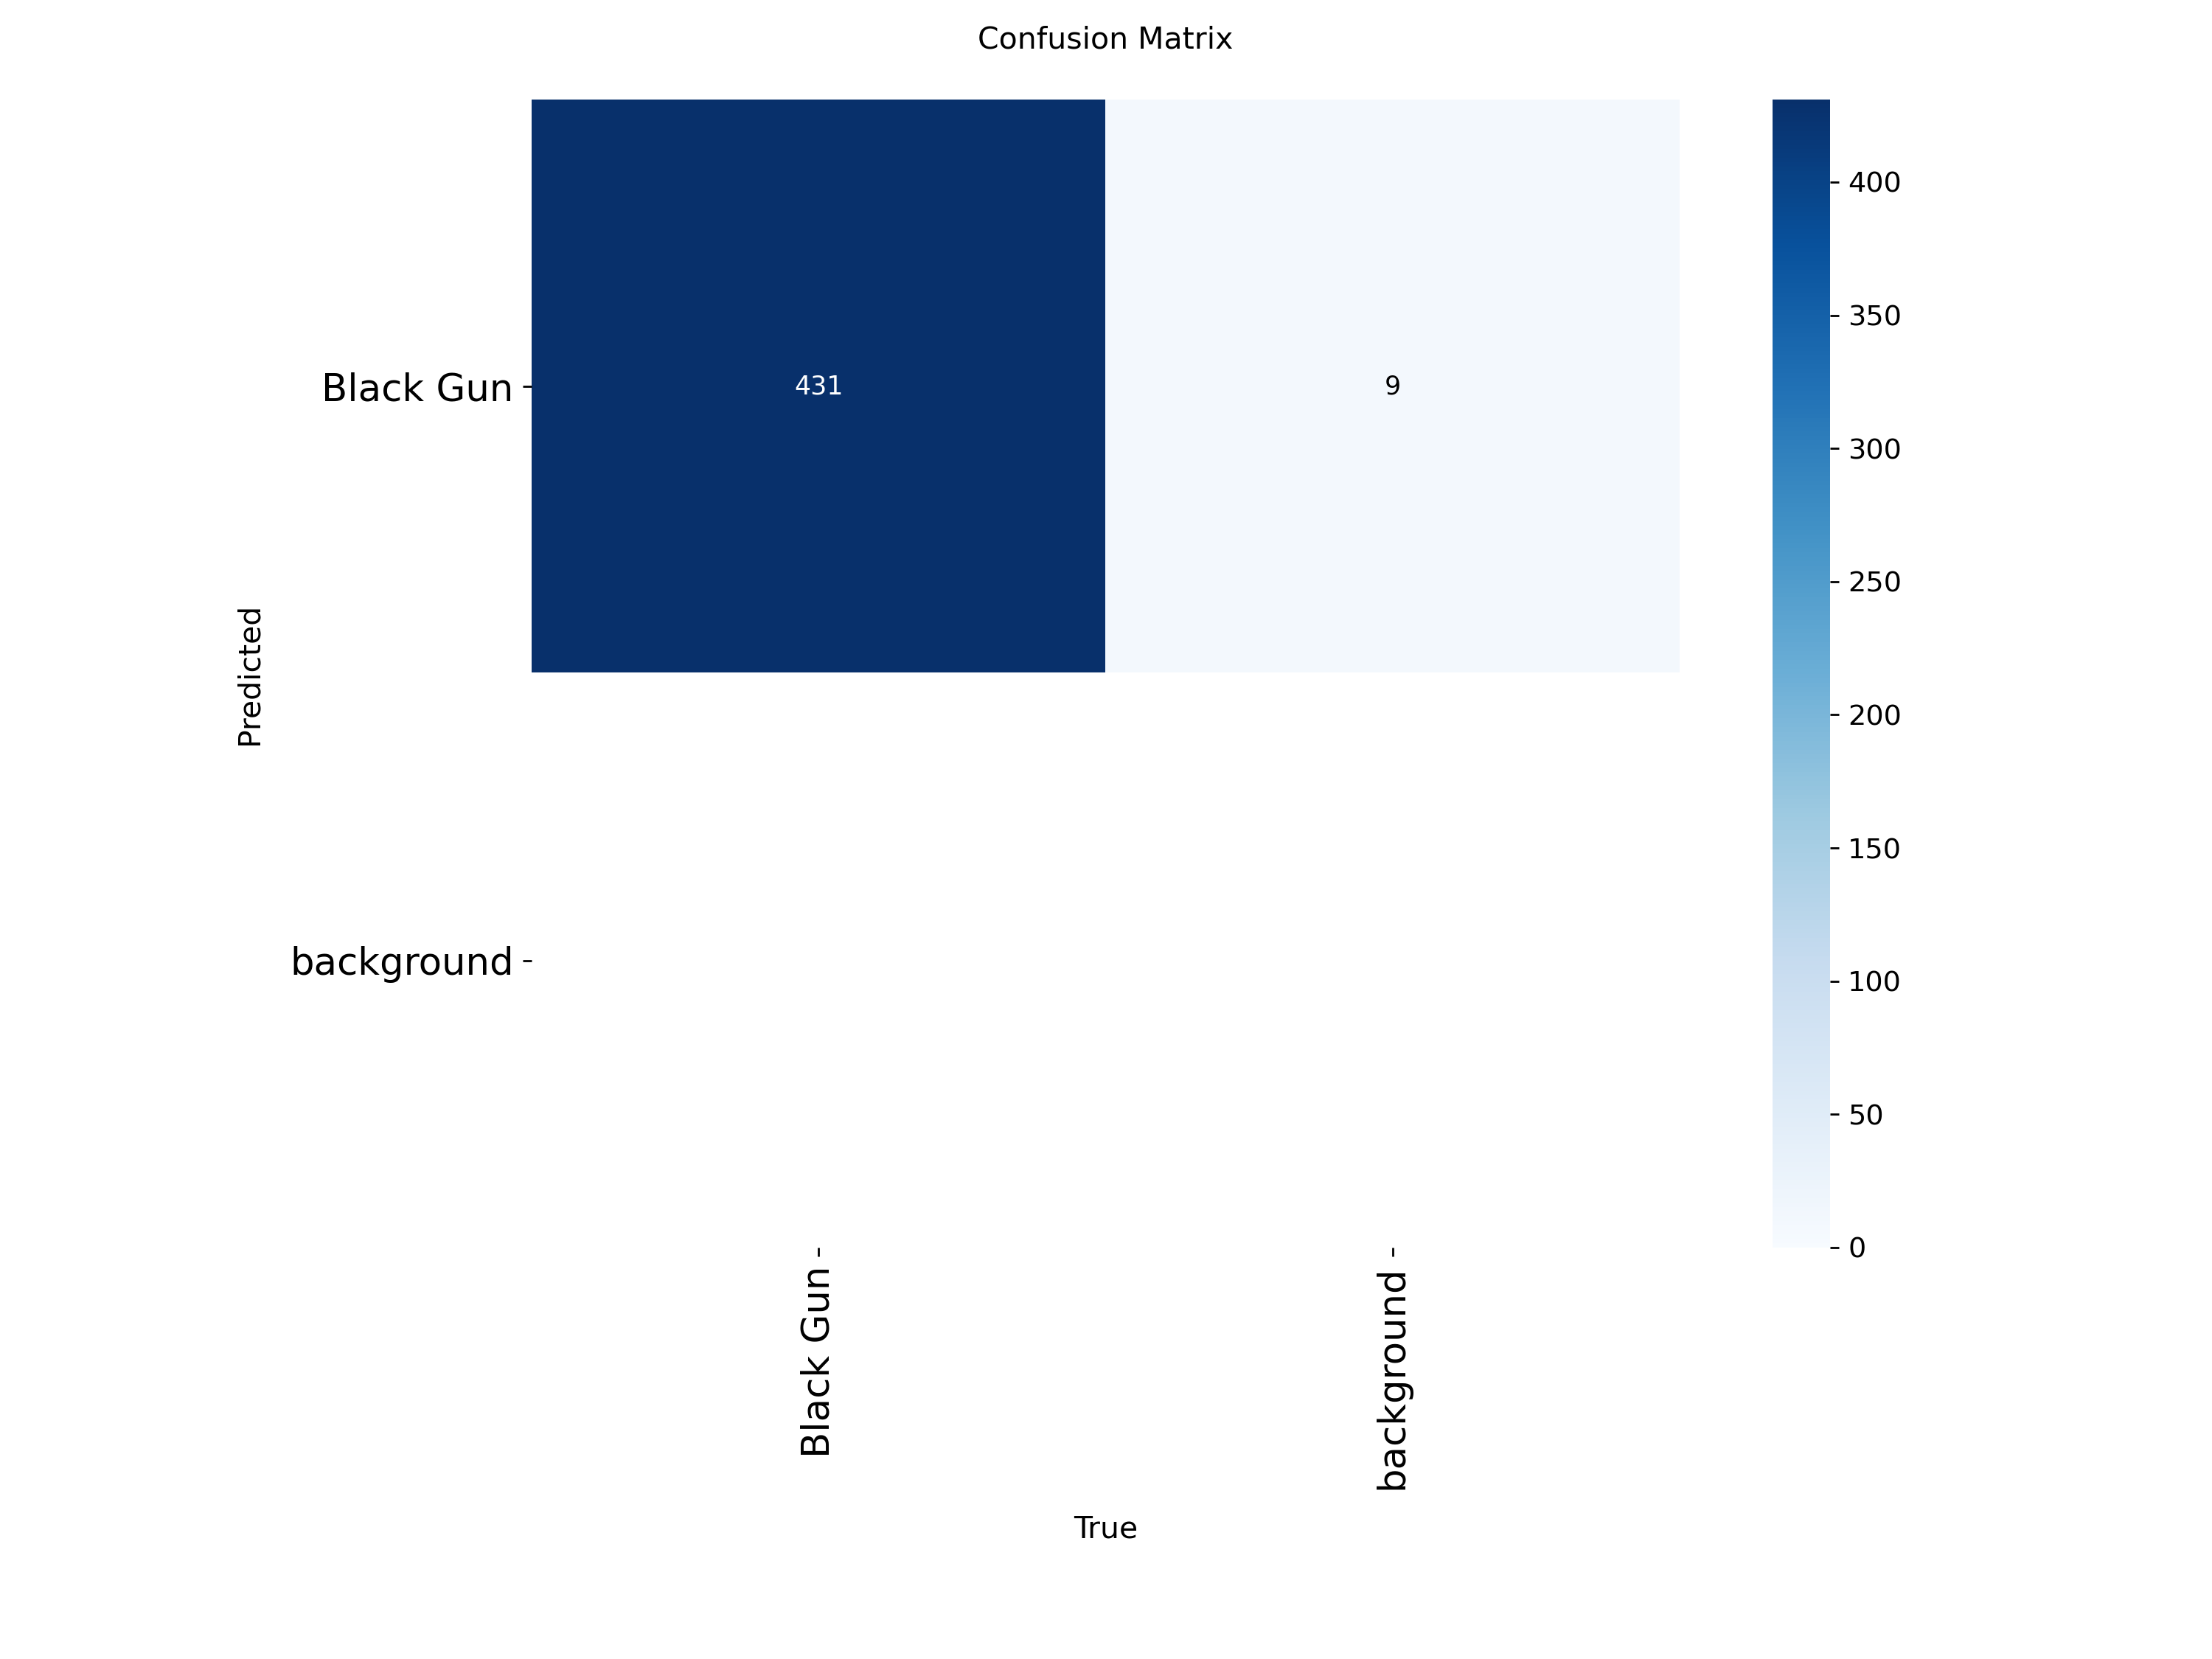


Evaluating Run: gun_detection_run_syn_v3 (704ef9d9174346c9a8f0df646618e41a)
Model Weights: d:\_pribadi\gun_detection\mlruns\704ef9d9174346c9a8f0df646618e41a\artifacts\weights\best.pt
Data Config: data/data_syn_v3.yaml

Ultralytics 8.4.12  Python-3.10.11 torch-2.10.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 1879.5539.6 MB/s, size: 1129.5 KB)
val: Scanning D:\_pribadi\gun_detection\data\labels\test... 185 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 185/185 315.9it/s 0.6s0.1s
val: New cache created: D:\_pribadi\gun_detection\data\labels\test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 4.8it/s 2.5s0.1s
                   all        185        185      0.989          1      0.995      0.994
Speed: 2.0ms preprocess, 4.0ms inference, 0.0ms loss, 0.6ms postprocess

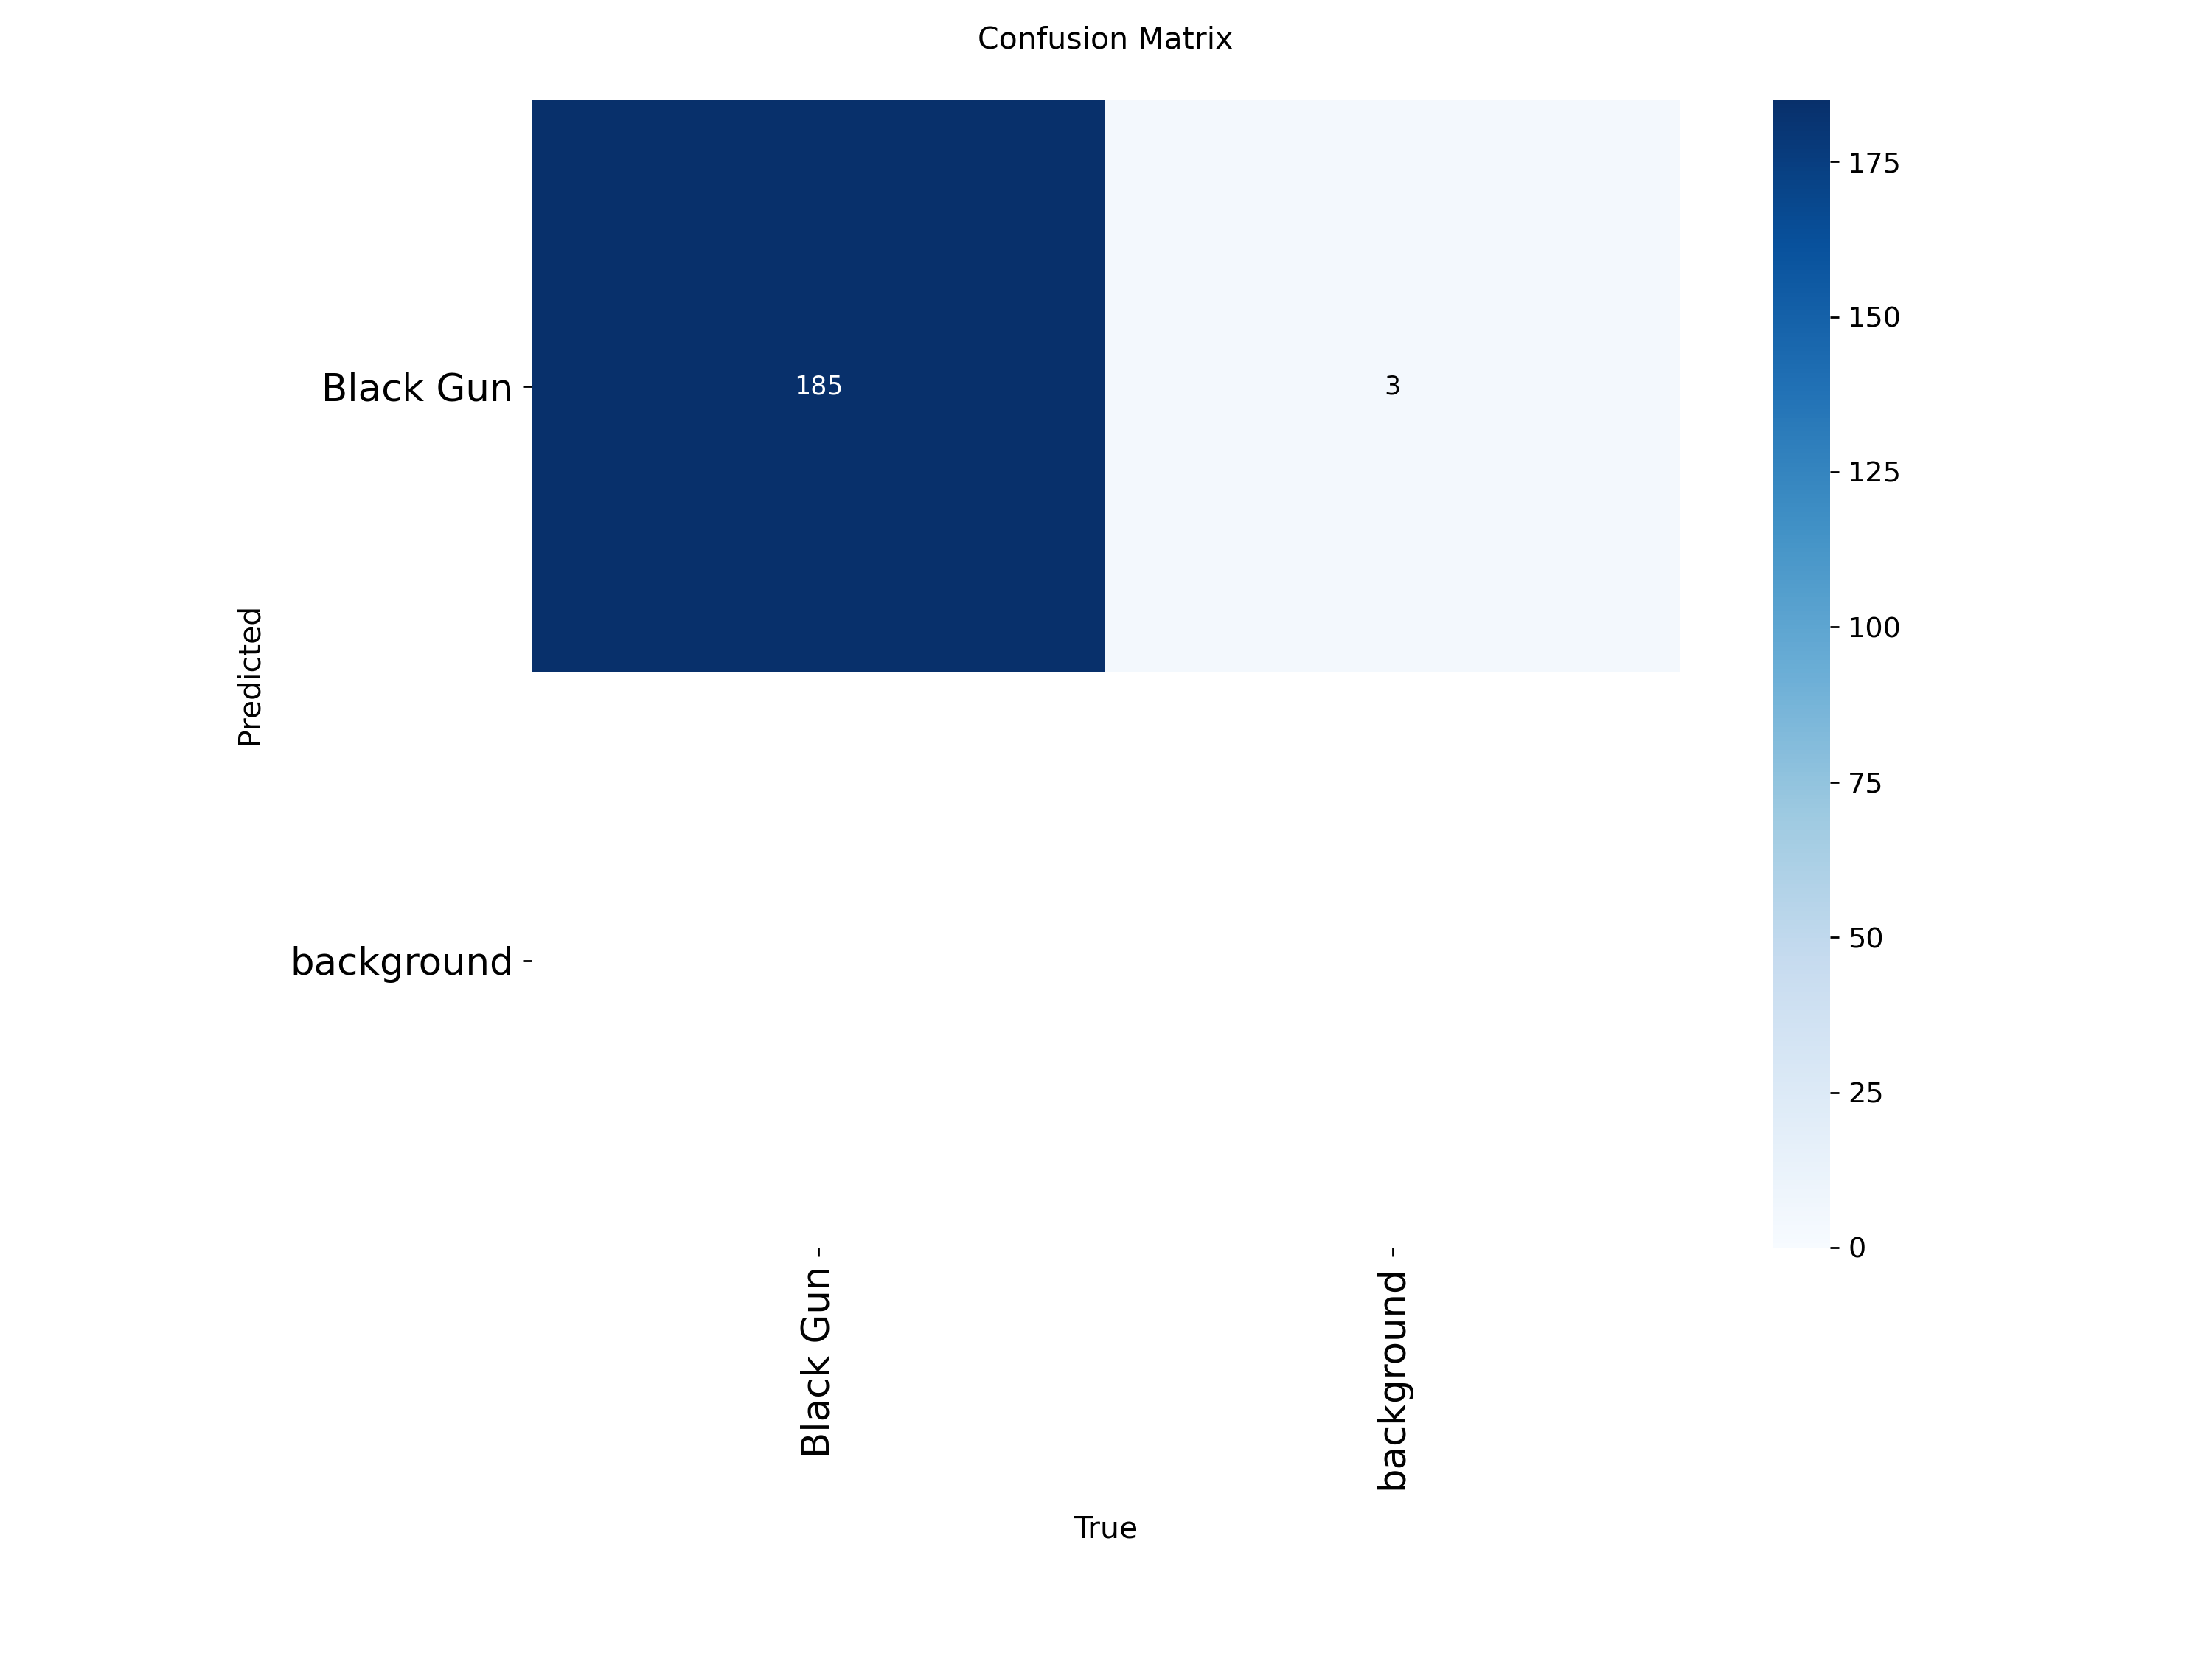


Evaluating Run: gun_detection_run_real_syn_v2 (487afaeed6c44b2eb161d947a0398e6e)
Model Weights: d:\_pribadi\gun_detection\mlruns\487afaeed6c44b2eb161d947a0398e6e\artifacts\weights\best.pt
Data Config: data/data_real_syn_v2.yaml

Ultralytics 8.4.12  Python-3.10.11 torch-2.10.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 581.7277.9 MB/s, size: 517.9 KB)
val: Scanning D:\_pribadi\gun_detection\data\labels\test... 296 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 296/296 790.2it/s 0.4s0.0s
val: New cache created: D:\_pribadi\gun_detection\data\labels\test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 8.4it/s 2.3s<0.1s
                   all        296        301      0.997          1      0.995      0.944
Speed: 1.1ms preprocess, 3.1ms inference, 0.0ms loss, 0.4ms po

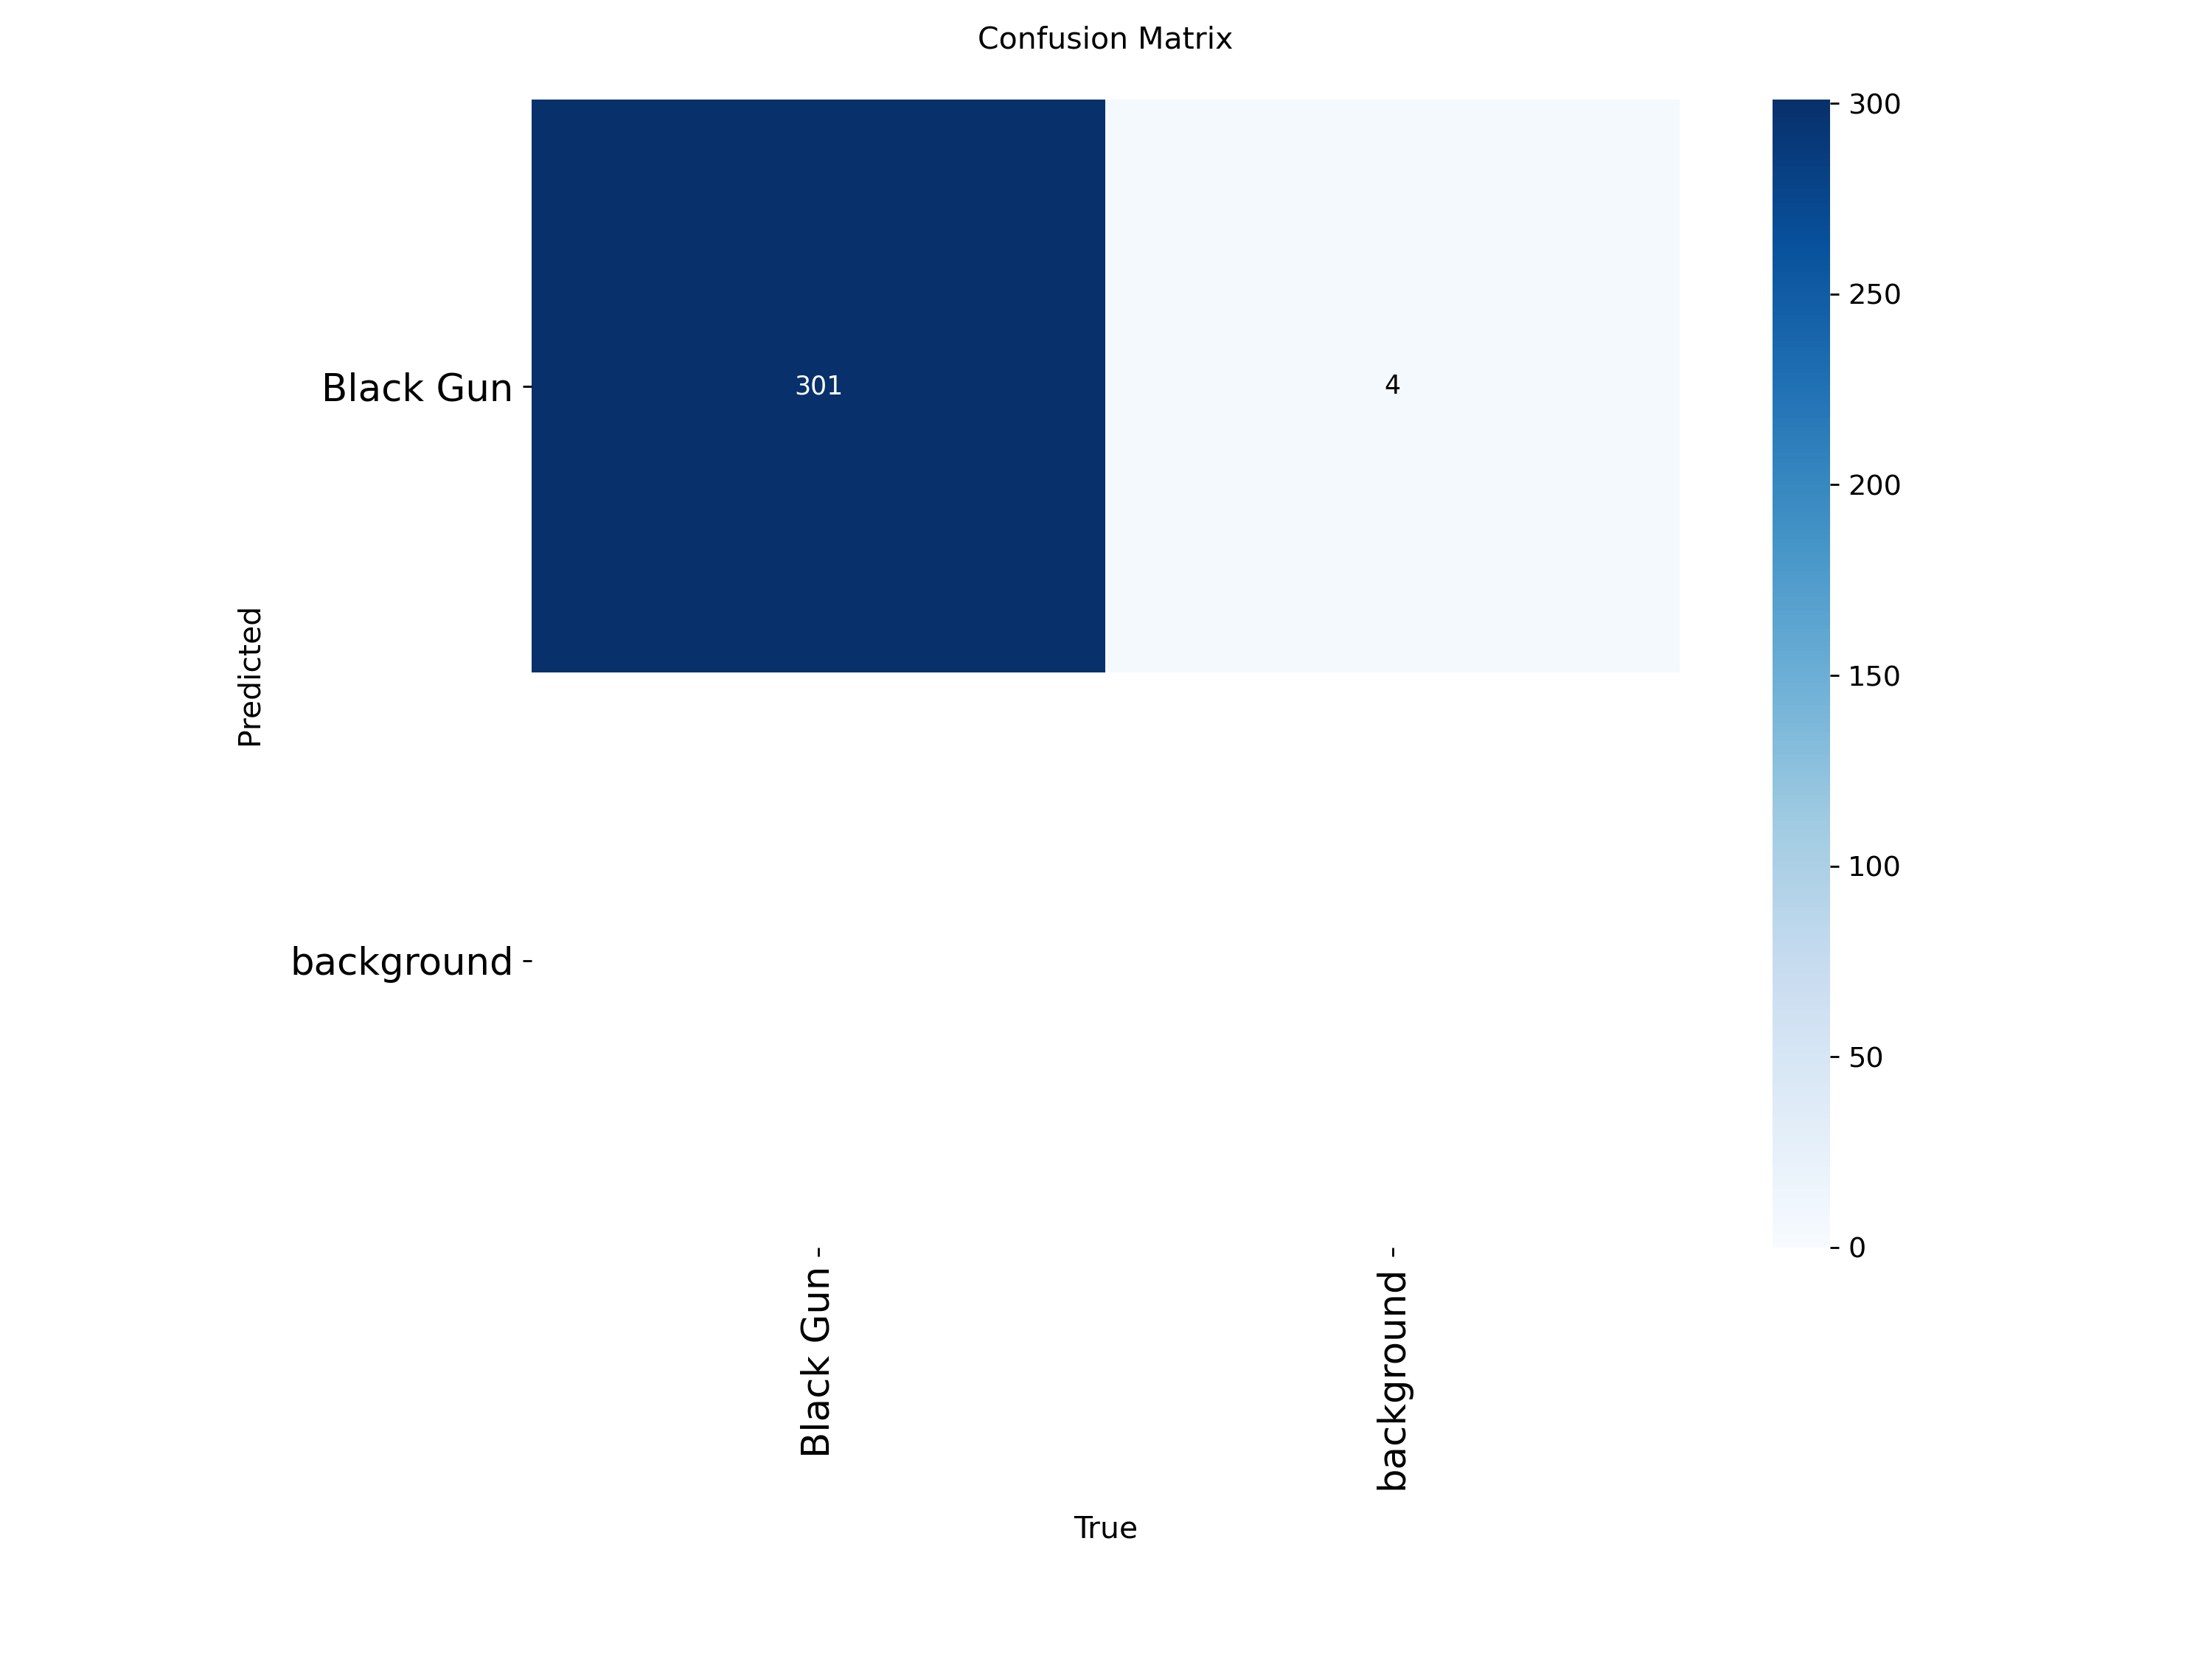


Evaluating Run: gun_detection_run_syn_v2 (6e83b006979b4033948822646f9901ea)
Model Weights: d:\_pribadi\gun_detection\mlruns\6e83b006979b4033948822646f9901ea\artifacts\weights\best.pt
Data Config: data/data_syn_v2.yaml

Ultralytics 8.4.12  Python-3.10.11 torch-2.10.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access  (ping: 0.10.1 ms, read: 868.0101.3 MB/s, size: 2113.3 KB)
val: Scanning D:\_pribadi\gun_detection\data\labels\test... 55 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 55/55 213.3it/s 0.3s.2s
val: New cache created: D:\_pribadi\gun_detection\data\labels\test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.1s/it 4.4s0.4s9s
                   all         55         55          1      0.999      0.995      0.876
Speed: 1.8ms preprocess, 9.0ms inference, 0.0ms loss, 1.5ms postprocess per 

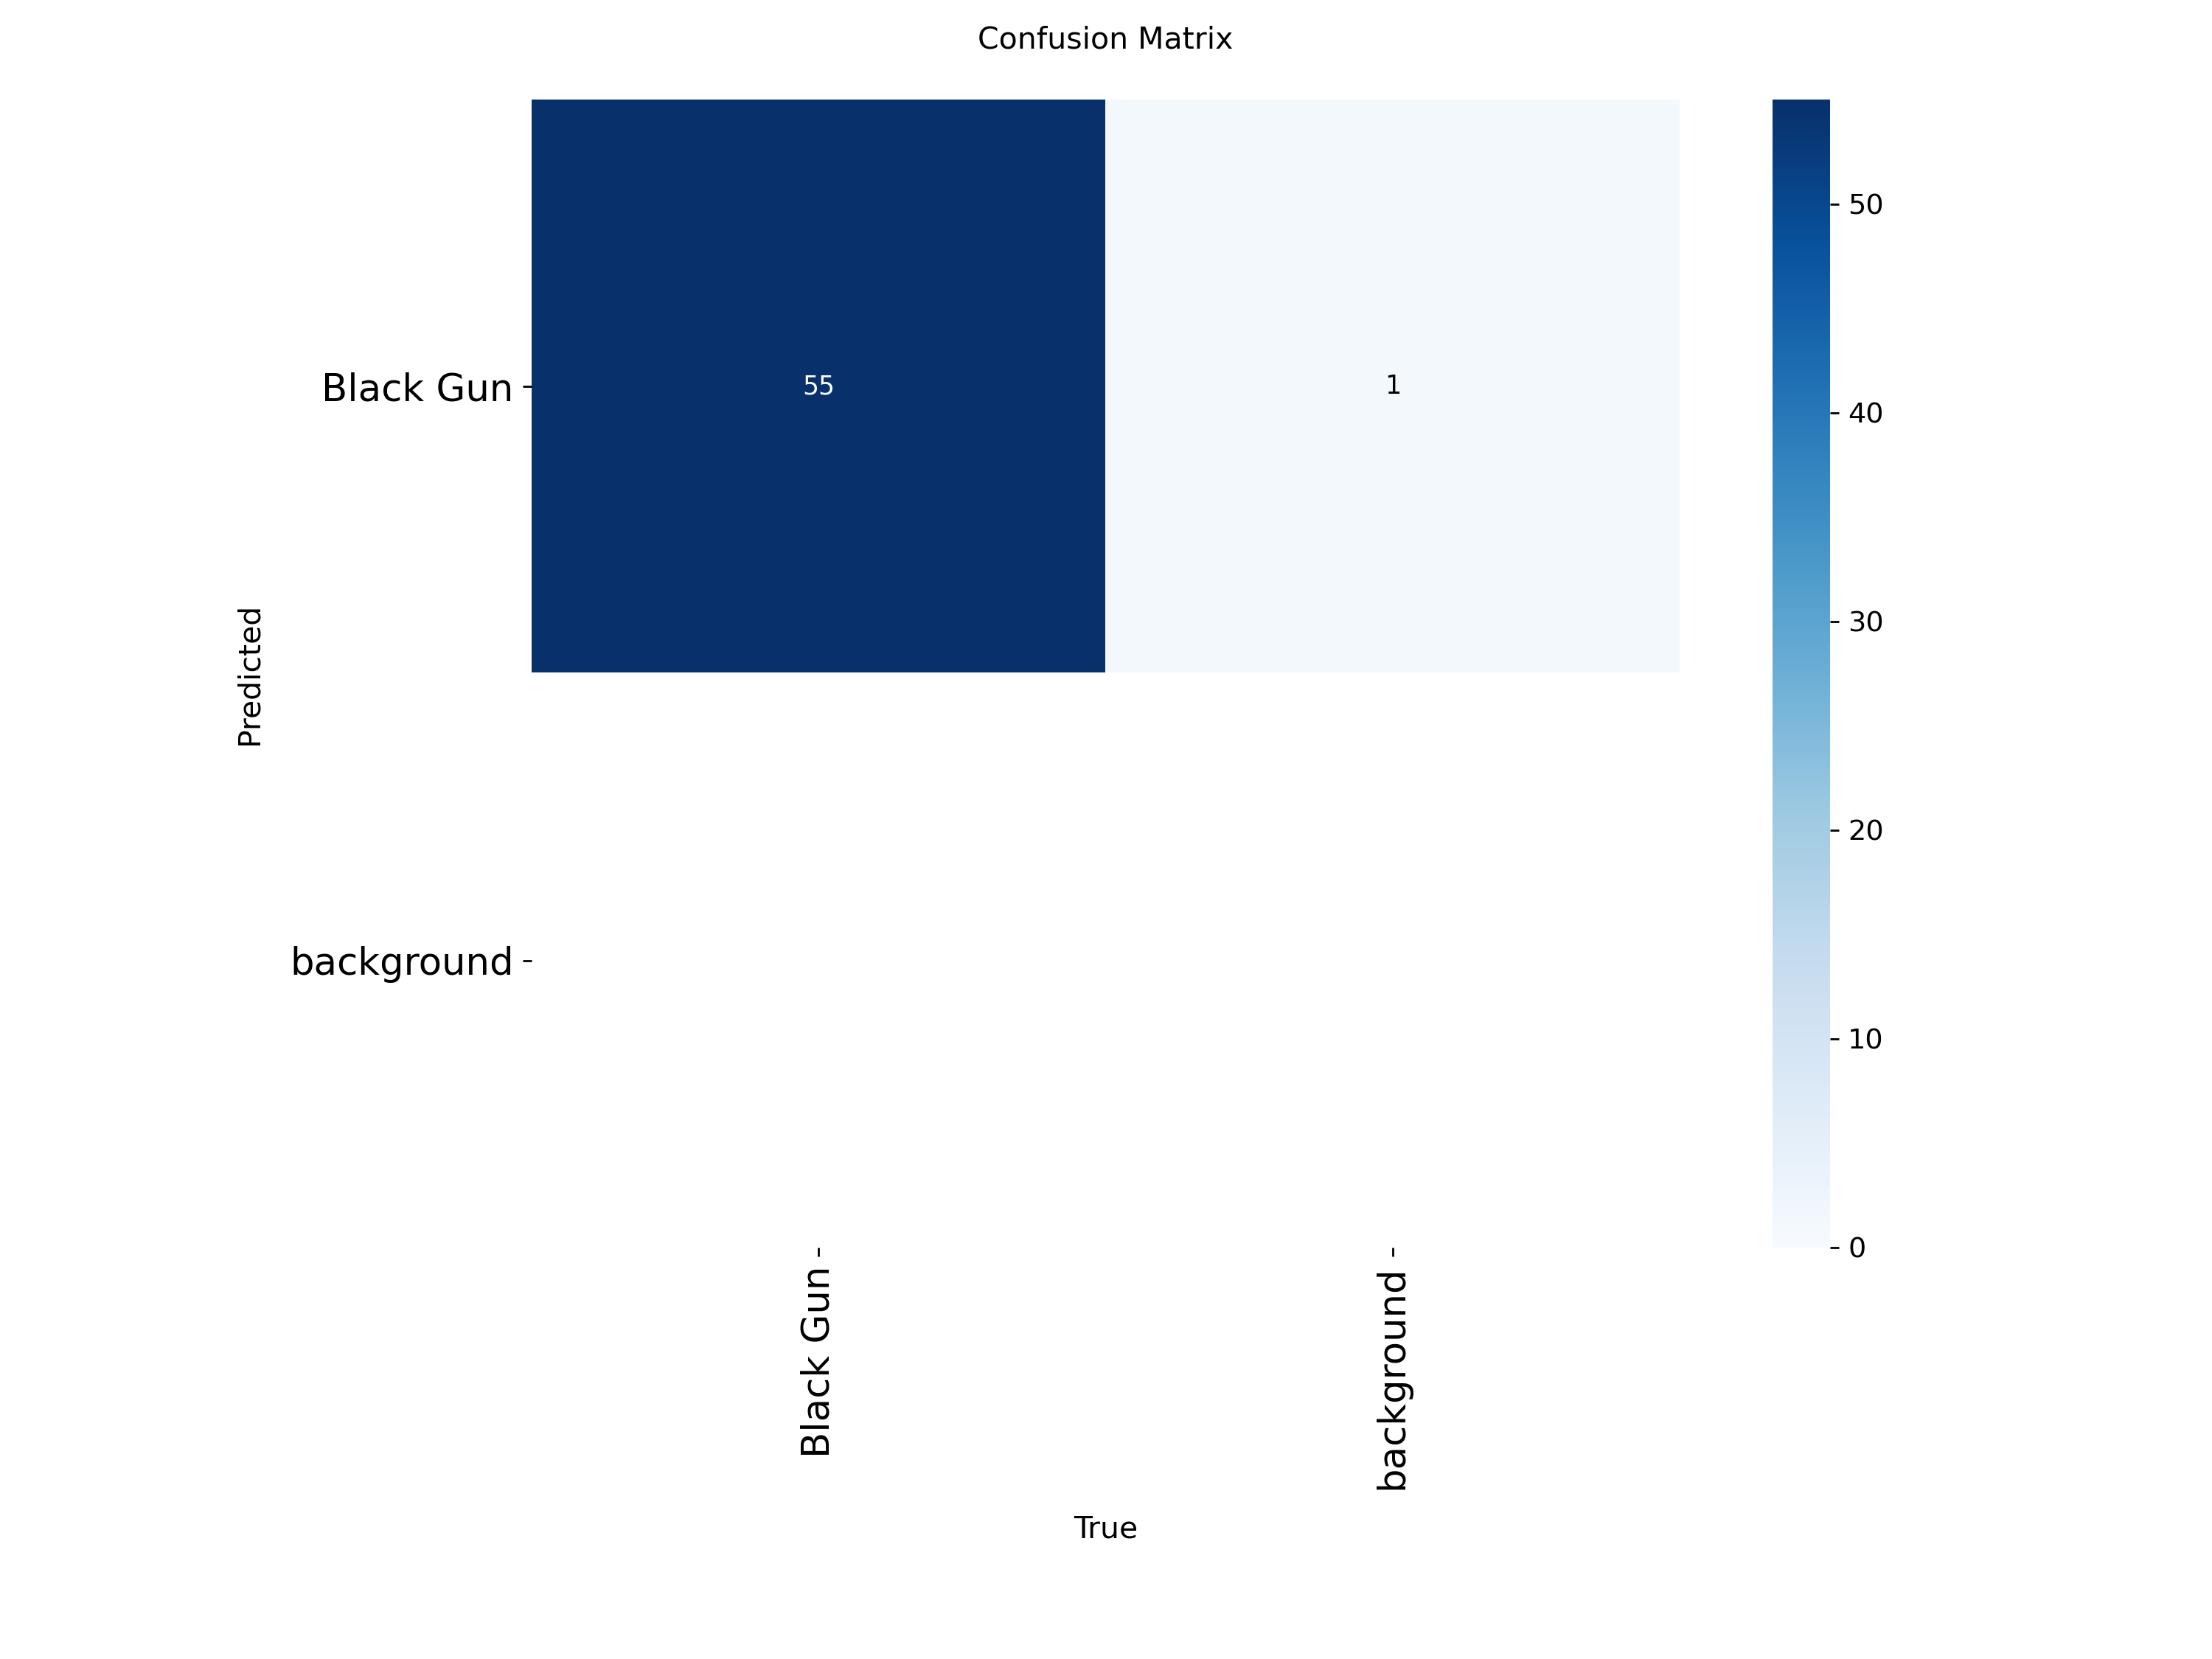


Evaluating Run: gun_detection_run_real (3c9276e87d984ecfa08832c03b87408e)
Model Weights: d:\_pribadi\gun_detection\mlruns\3c9276e87d984ecfa08832c03b87408e\artifacts\weights\best.pt
Data Config: data/data_real.yaml

Ultralytics 8.4.12  Python-3.10.11 torch-2.10.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 183.4124.9 MB/s, size: 81.5 KB)
val: Scanning D:\_pribadi\gun_detection\data\labels\test... 241 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 241/241 3.3Kit/s 0.1s
val: New cache created: D:\_pribadi\gun_detection\data\labels\test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 6.4it/s 2.5s<0.1s
                   all        241        246      0.987          1      0.995      0.955
Speed: 1.3ms preprocess, 5.3ms inference, 0.0ms loss, 0.4ms postprocess per image


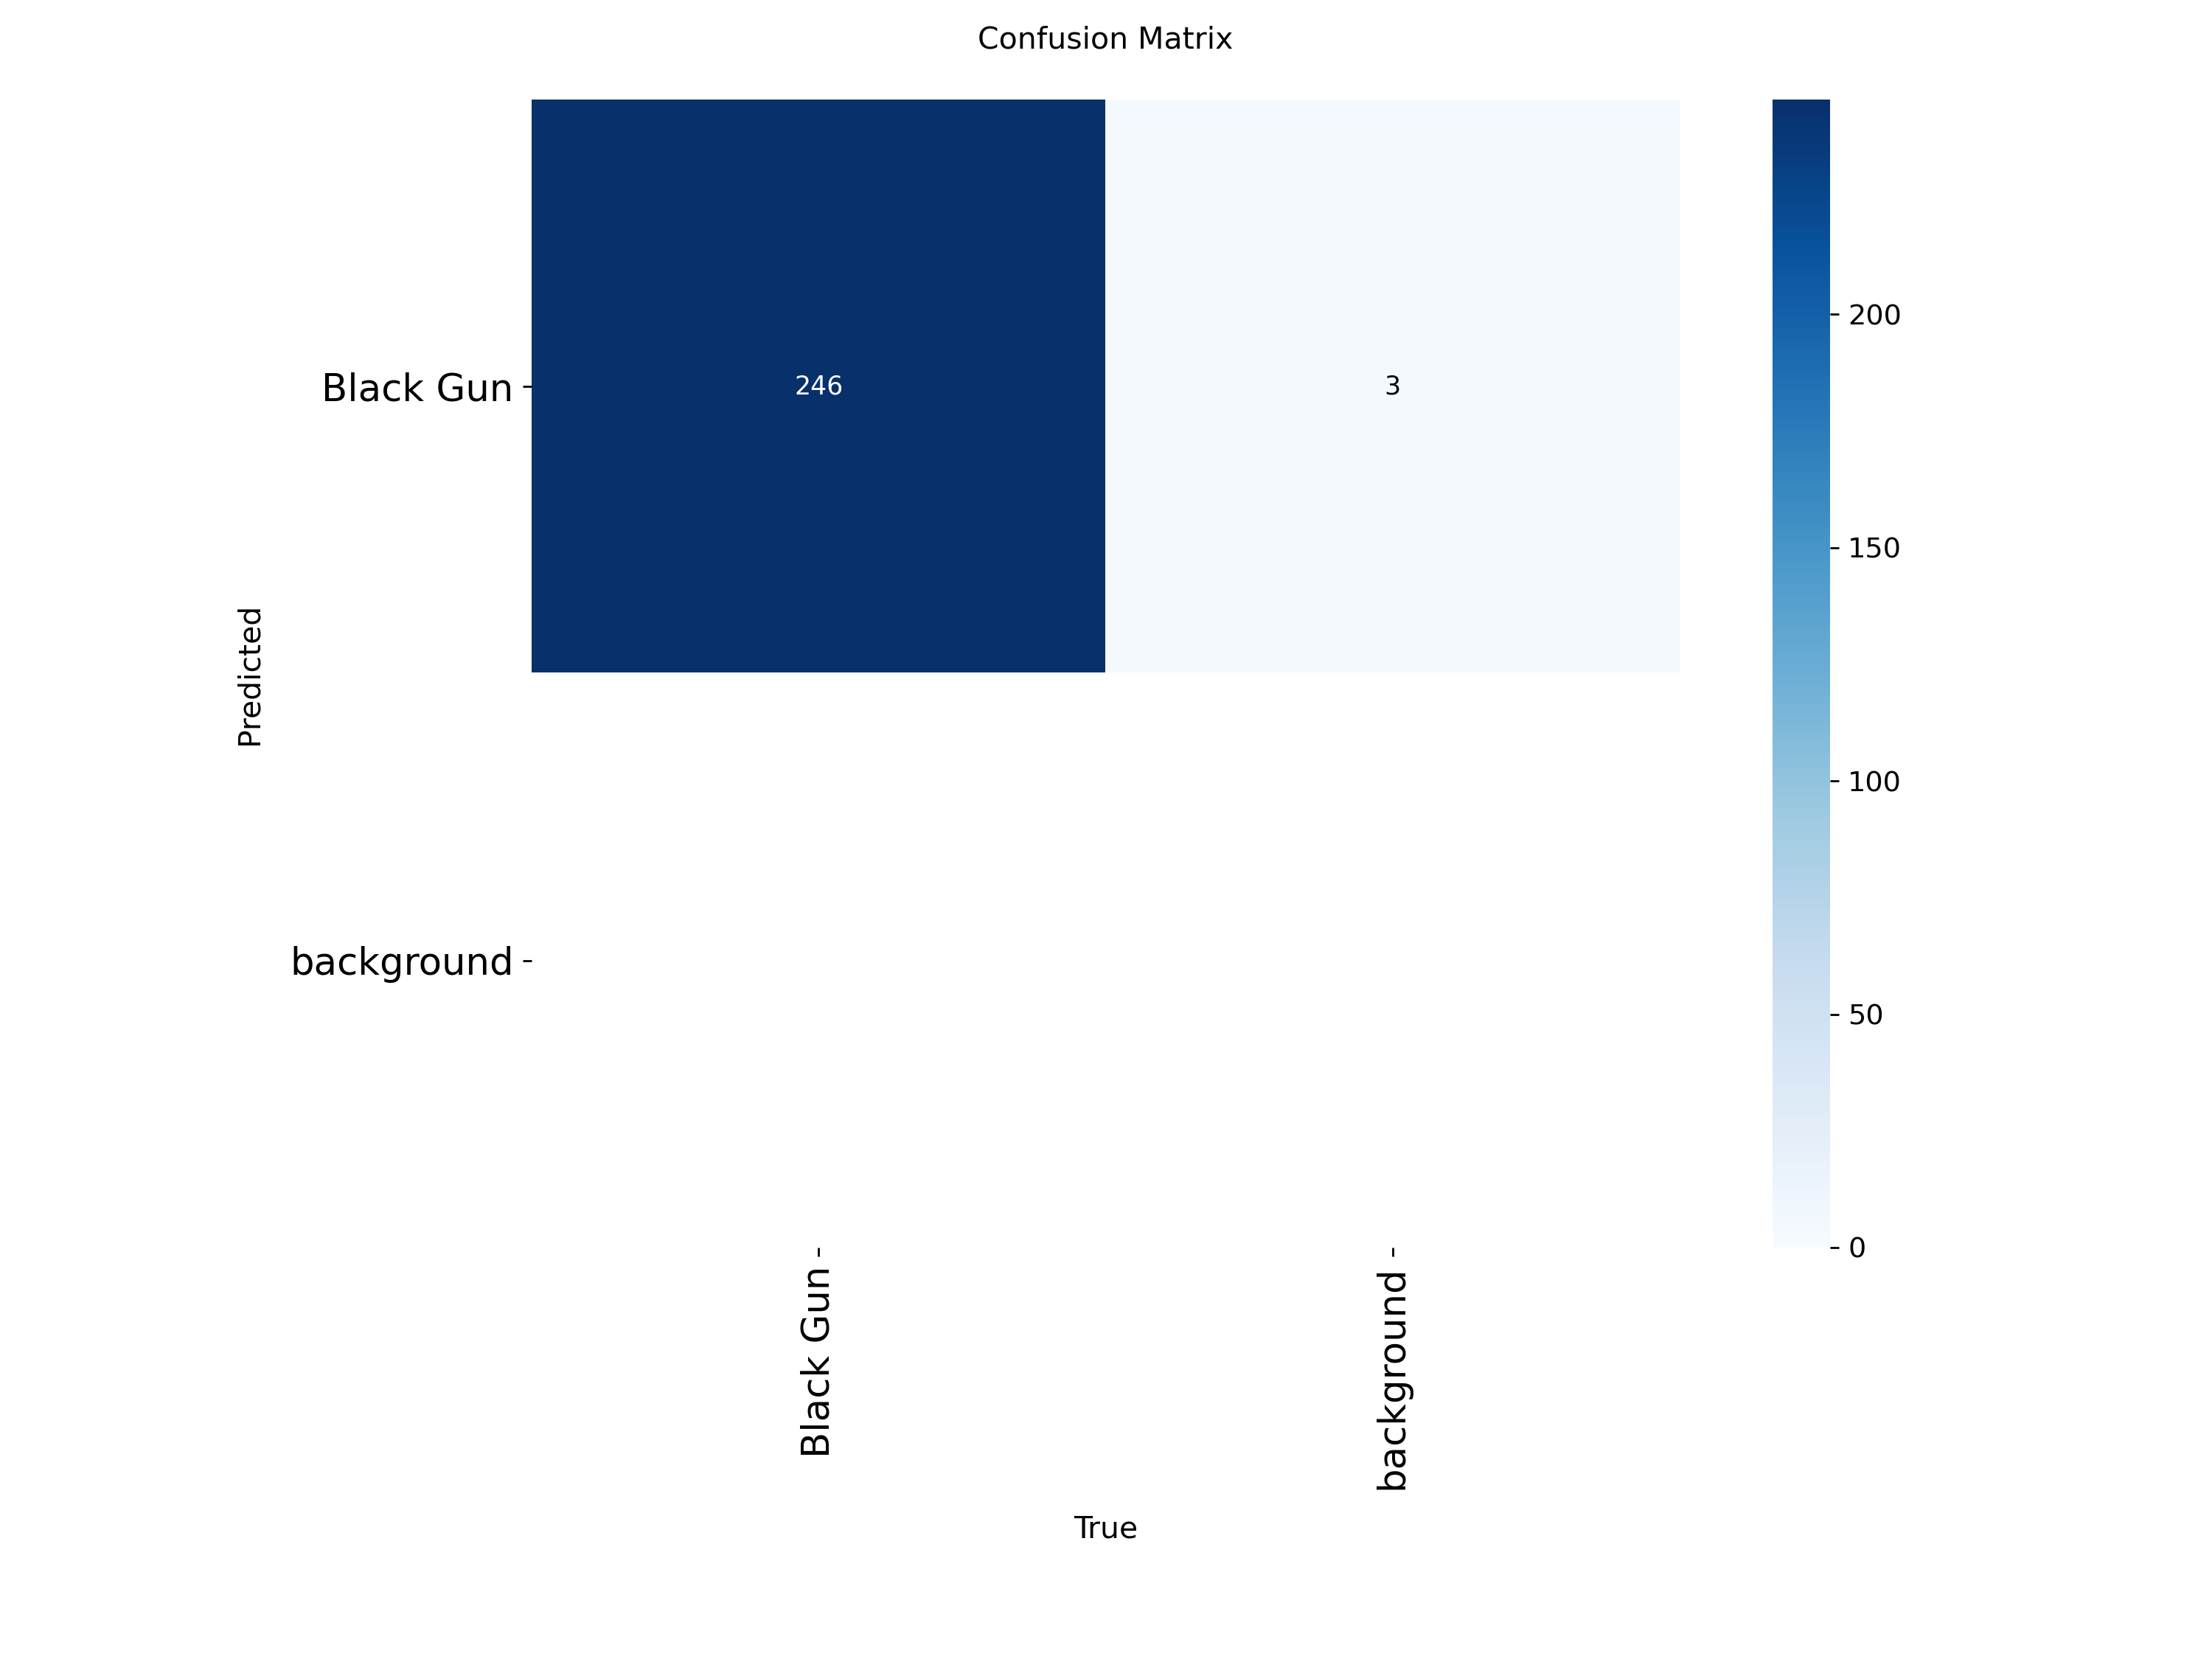

In [5]:
# --- Evaluation Loop ---

for run_info in evaluated_runs:
    print(f"\n{'='*50}")
    print(f"Evaluating Run: {run_info['run_name']} ({run_info['run_id']})")
    print(f"Model Weights: {run_info['weights']}")
    print(f"Data Config: {run_info['data']}")
    print(f"{'='*50}\n")
    
    # Load Model
    try:
        project_path = f"runs/test/{run_info['run_name']}"
        os.makedirs(project_path, exist_ok=True)
        model = YOLO(run_info['weights'])
        
        # Evaluate on Test Split
        # The 'data' config contains the 'test' path which is used as ground truth
        metrics = model.val(
            data=run_info['data'],
            split='test',
            device='cuda:0' if torch.cuda.is_available() else 'cpu',
            project=os.path.abspath("runs/test"),
            name=run_info['run_name'],
            exist_ok=True,
            plots=True
        )
        
        # Display Metrics
        print(f"\nResults for {run_info['run_name']}:")
        print(f"mAP50: {metrics.box.map50:.4f}")
        print(f"mAP50-95: {metrics.box.map:.4f}")
        
        # Display Confusion Matrix
        # YOLO saves it in the project/name directory
        save_dir = metrics.save_dir
        cm_path = os.path.join(save_dir, "confusion_matrix.png")
        
        if os.path.exists(cm_path):
            print("Confusion Matrix:")
            display(Image(filename=cm_path))
        else:
            # Fallback check for normalized CM
            cm_norm_path = os.path.join(save_dir, "confusion_matrix_normalized.png")
            if os.path.exists(cm_norm_path):
                 print("Normalized Confusion Matrix:")
                 display(Image(filename=cm_norm_path))
            else:
                print("Confusion Matrix not found in output directory.")

    except Exception as e:
        print(f"Error evaluating run {run_info['run_id']}: {e}")


Evaluating Run: gun_detection_run_real_syn_v3 (94a5fa9b3c5e4fb39db3988aaef884d8)
Model Weights: d:\_pribadi\gun_detection\mlruns\94a5fa9b3c5e4fb39db3988aaef884d8\artifacts\weights\best.pt
Data Config: data/data_real_syn_v3.yaml

Ultralytics 8.4.12  Python-3.10.11 torch-2.10.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 983.7320.7 MB/s, size: 868.8 KB)
val: Scanning D:\_pribadi\gun_detection\data\labels\test... 481 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 481/481 588.2it/s 0.8s0.1s
val: New cache created: D:\_pribadi\gun_detection\data\labels\test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 31/31 8.6it/s 3.6s0.1ss
                   all        481        486      0.981       0.94      0.967      0.897
Speed: 1.9ms preprocess, 2.8ms inference, 0.0ms loss, 0.1ms po

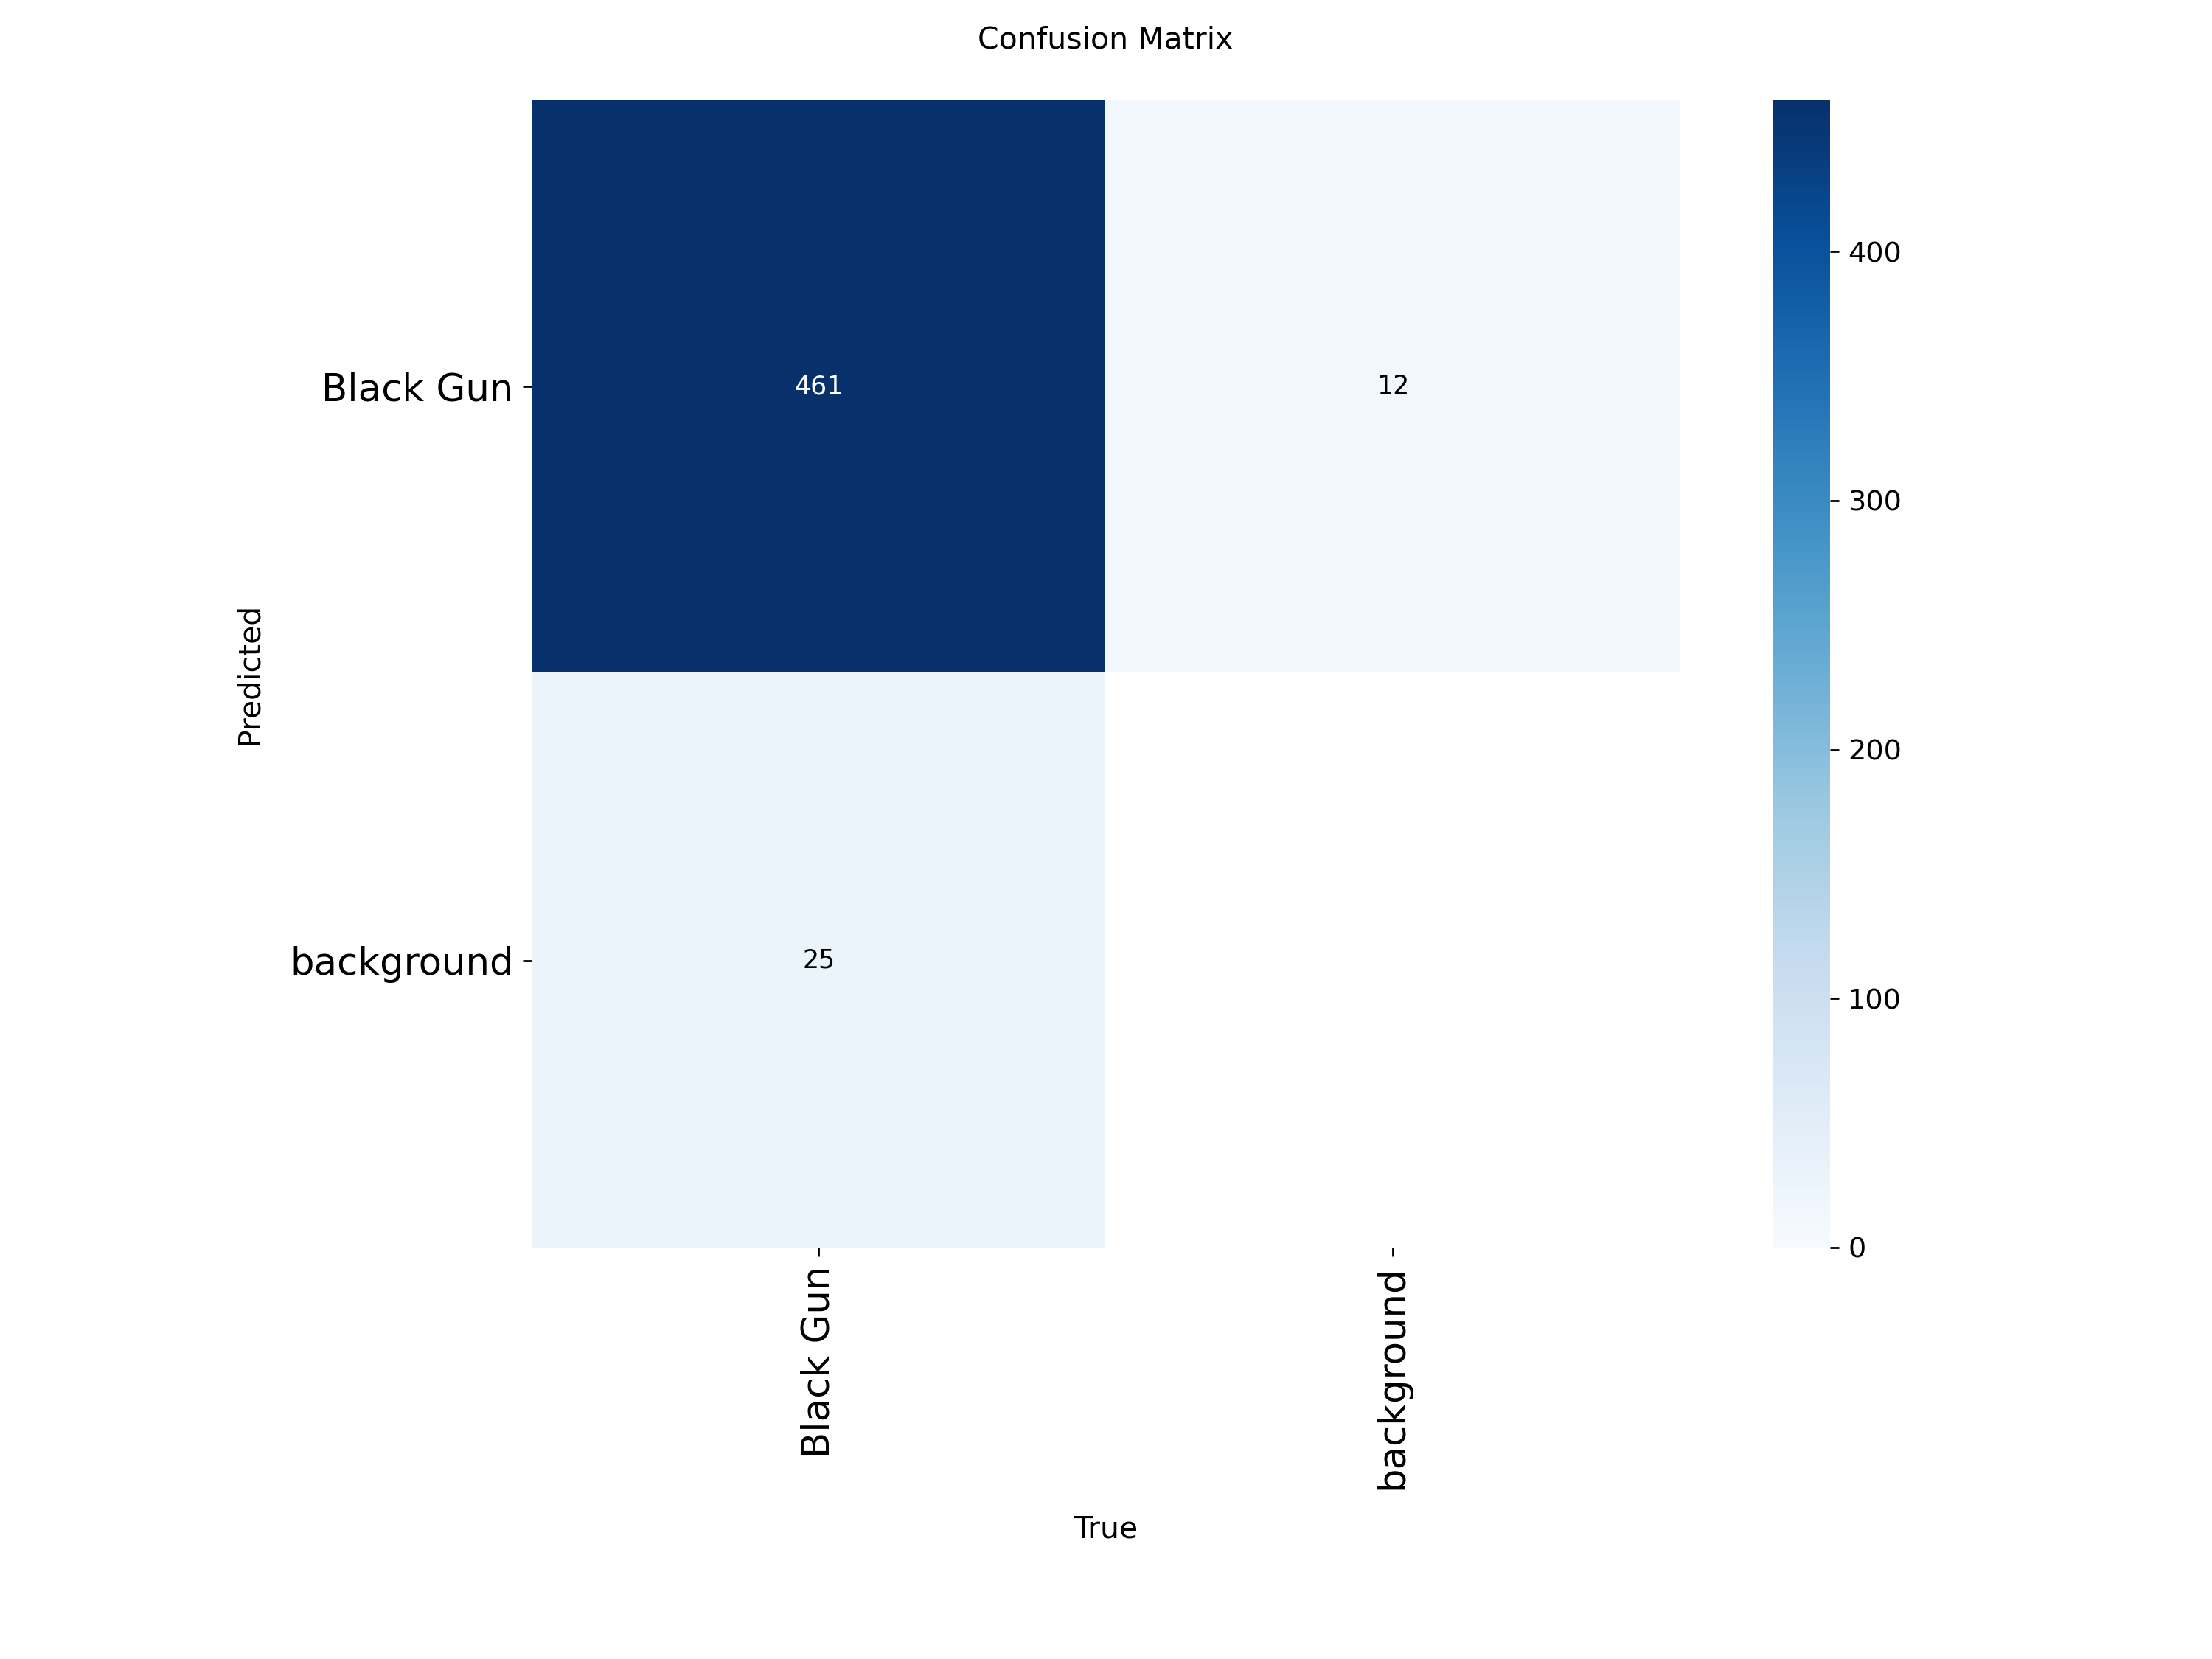


Evaluating Run: gun_detection_run_syn_v3 (704ef9d9174346c9a8f0df646618e41a)
Model Weights: d:\_pribadi\gun_detection\mlruns\704ef9d9174346c9a8f0df646618e41a\artifacts\weights\best.pt
Data Config: data/data_syn_v3.yaml

Ultralytics 8.4.12  Python-3.10.11 torch-2.10.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 871.6433.1 MB/s, size: 921.6 KB)
val: Scanning D:\_pribadi\gun_detection\data\labels\test.cache... 481 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 481/481  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 31/31 10.6it/s 2.9s0.1s
                   all        481        486      0.909      0.426      0.573      0.506
Speed: 0.9ms preprocess, 2.1ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to D:\_pribadi\gun_detection\runs\test\gun_detection_run

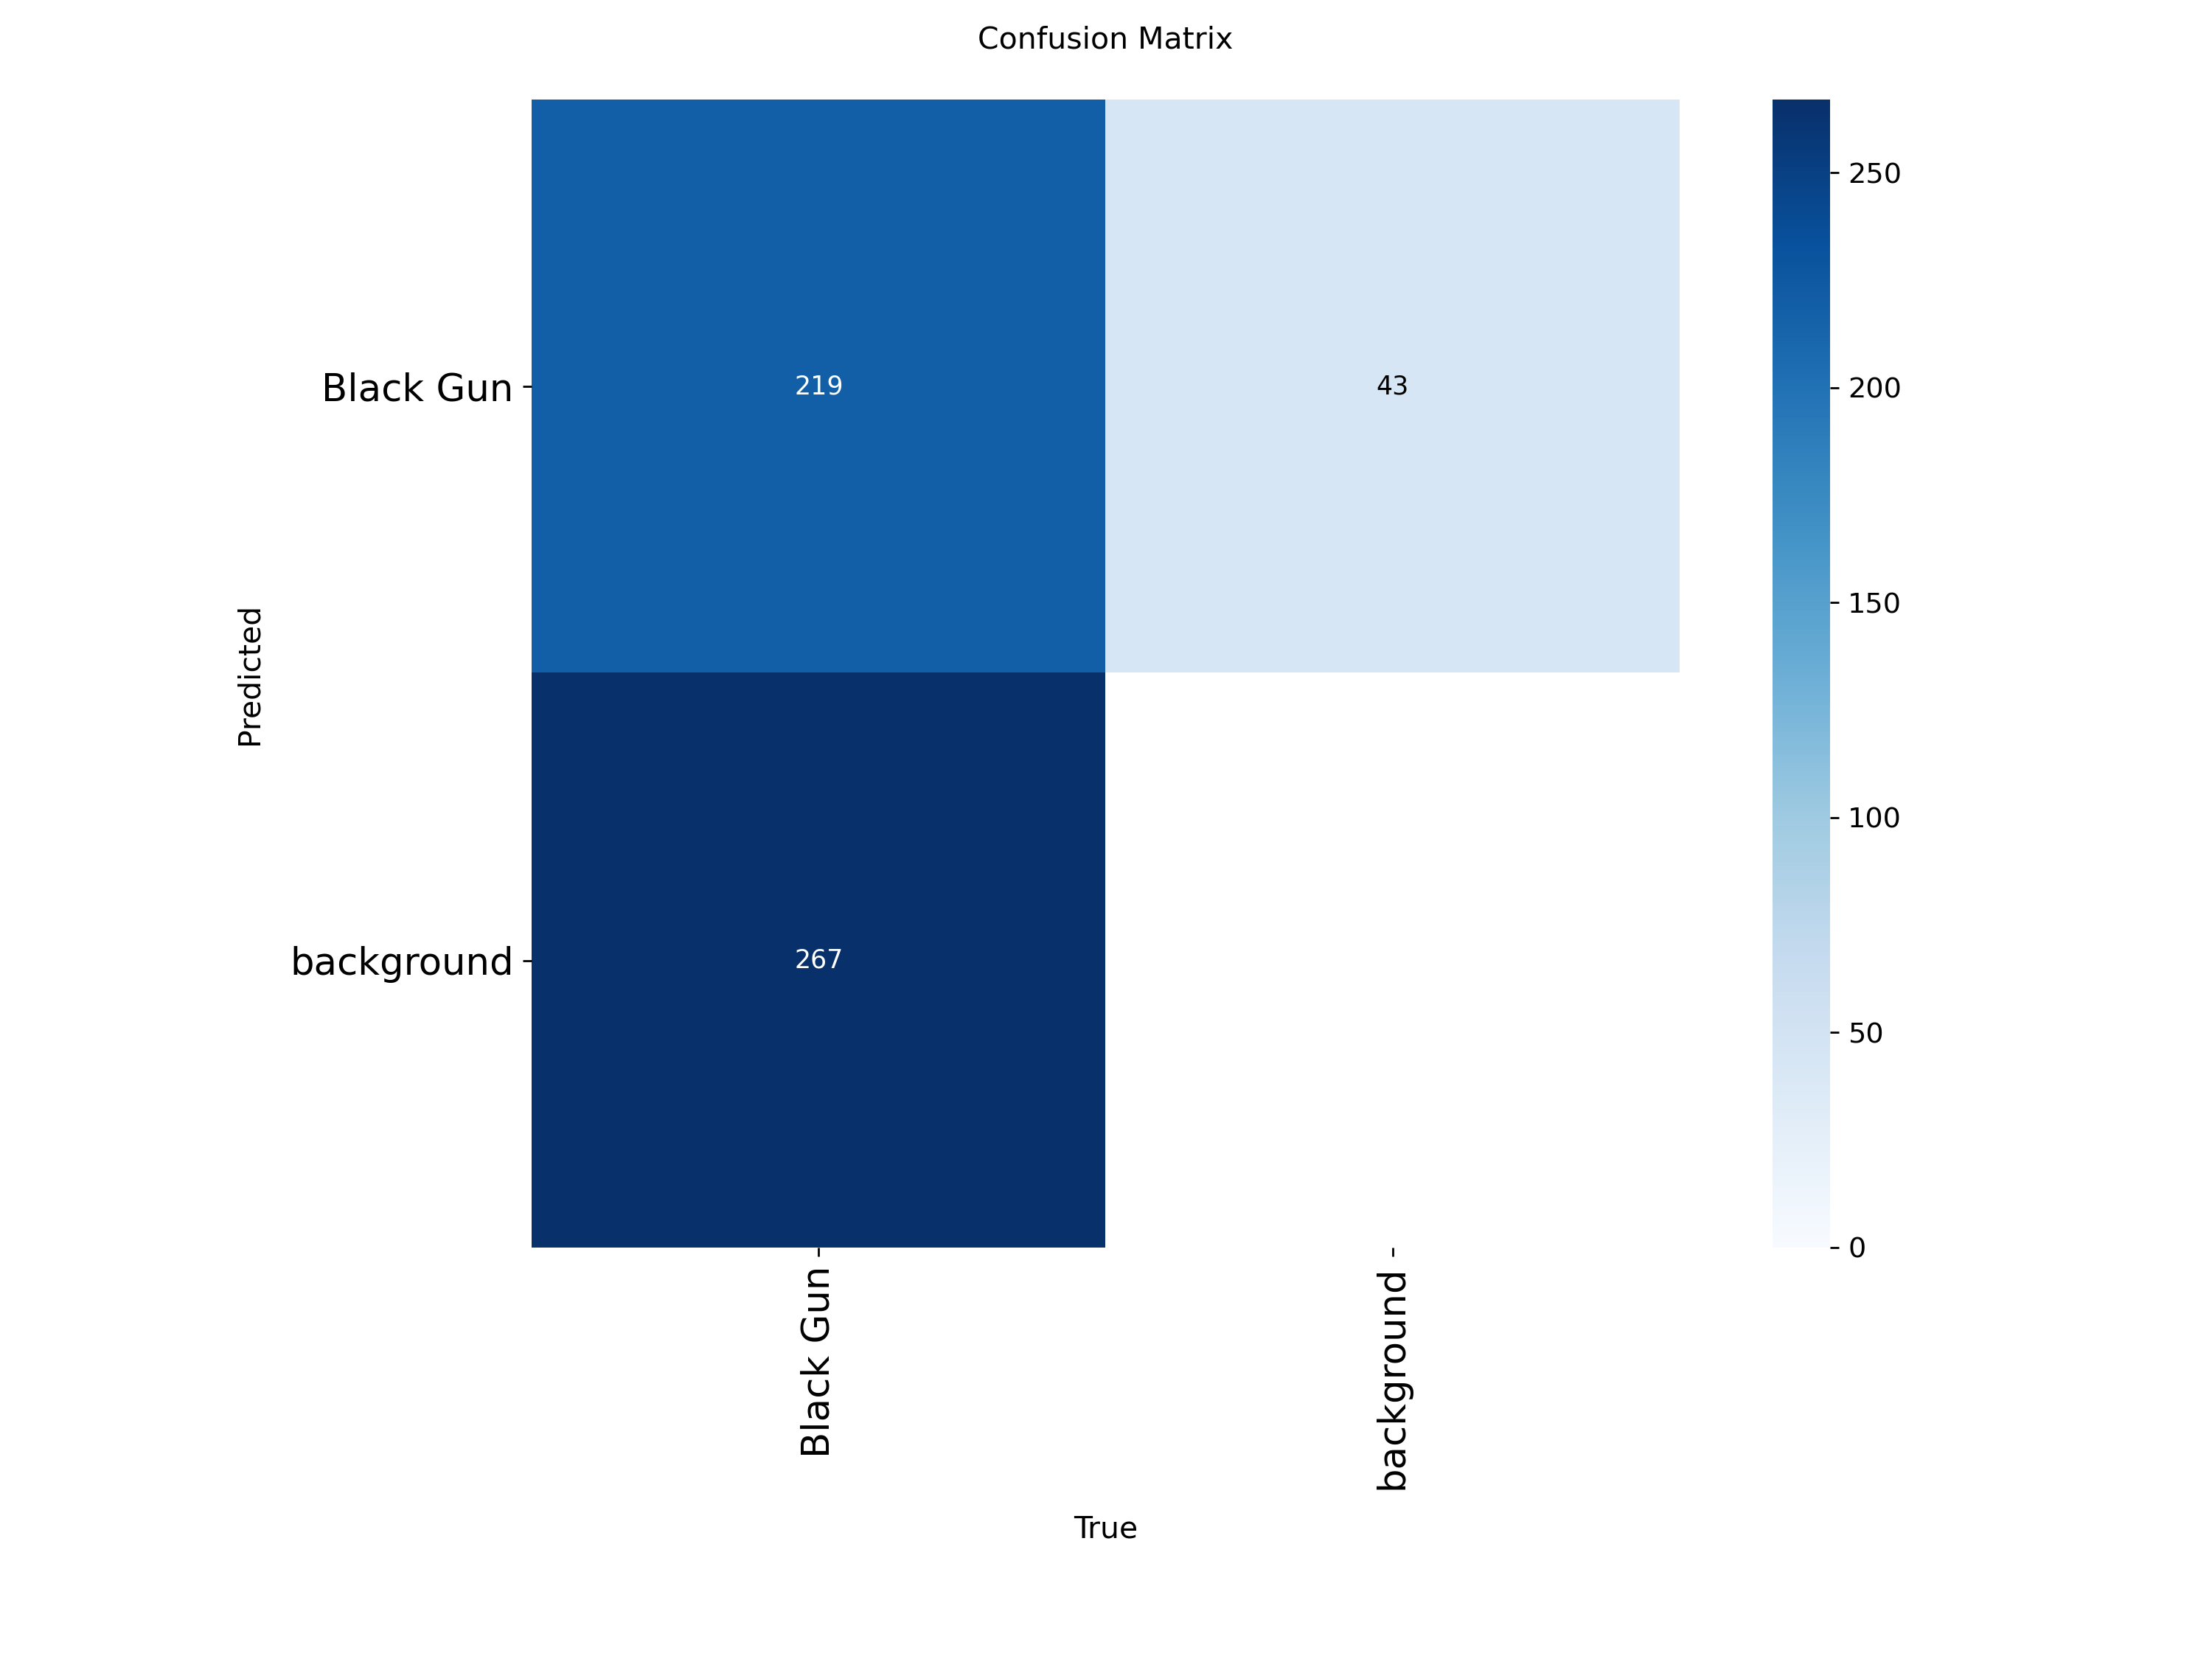


Evaluating Run: gun_detection_run_real_syn_v2 (487afaeed6c44b2eb161d947a0398e6e)
Model Weights: d:\_pribadi\gun_detection\mlruns\487afaeed6c44b2eb161d947a0398e6e\artifacts\weights\best.pt
Data Config: data/data_real_syn_v2.yaml

Ultralytics 8.4.12  Python-3.10.11 torch-2.10.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 2663.9159.5 MB/s, size: 1258.4 KB)
val: Scanning D:\_pribadi\gun_detection\data\labels\test.cache... 481 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 481/481  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 31/31 8.9it/s 3.5s<0.1s
                   all        481        486      0.994      0.976      0.994      0.793
Speed: 1.0ms preprocess, 2.1ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to D:\_pribadi\gun_detection\runs\test\gun_d

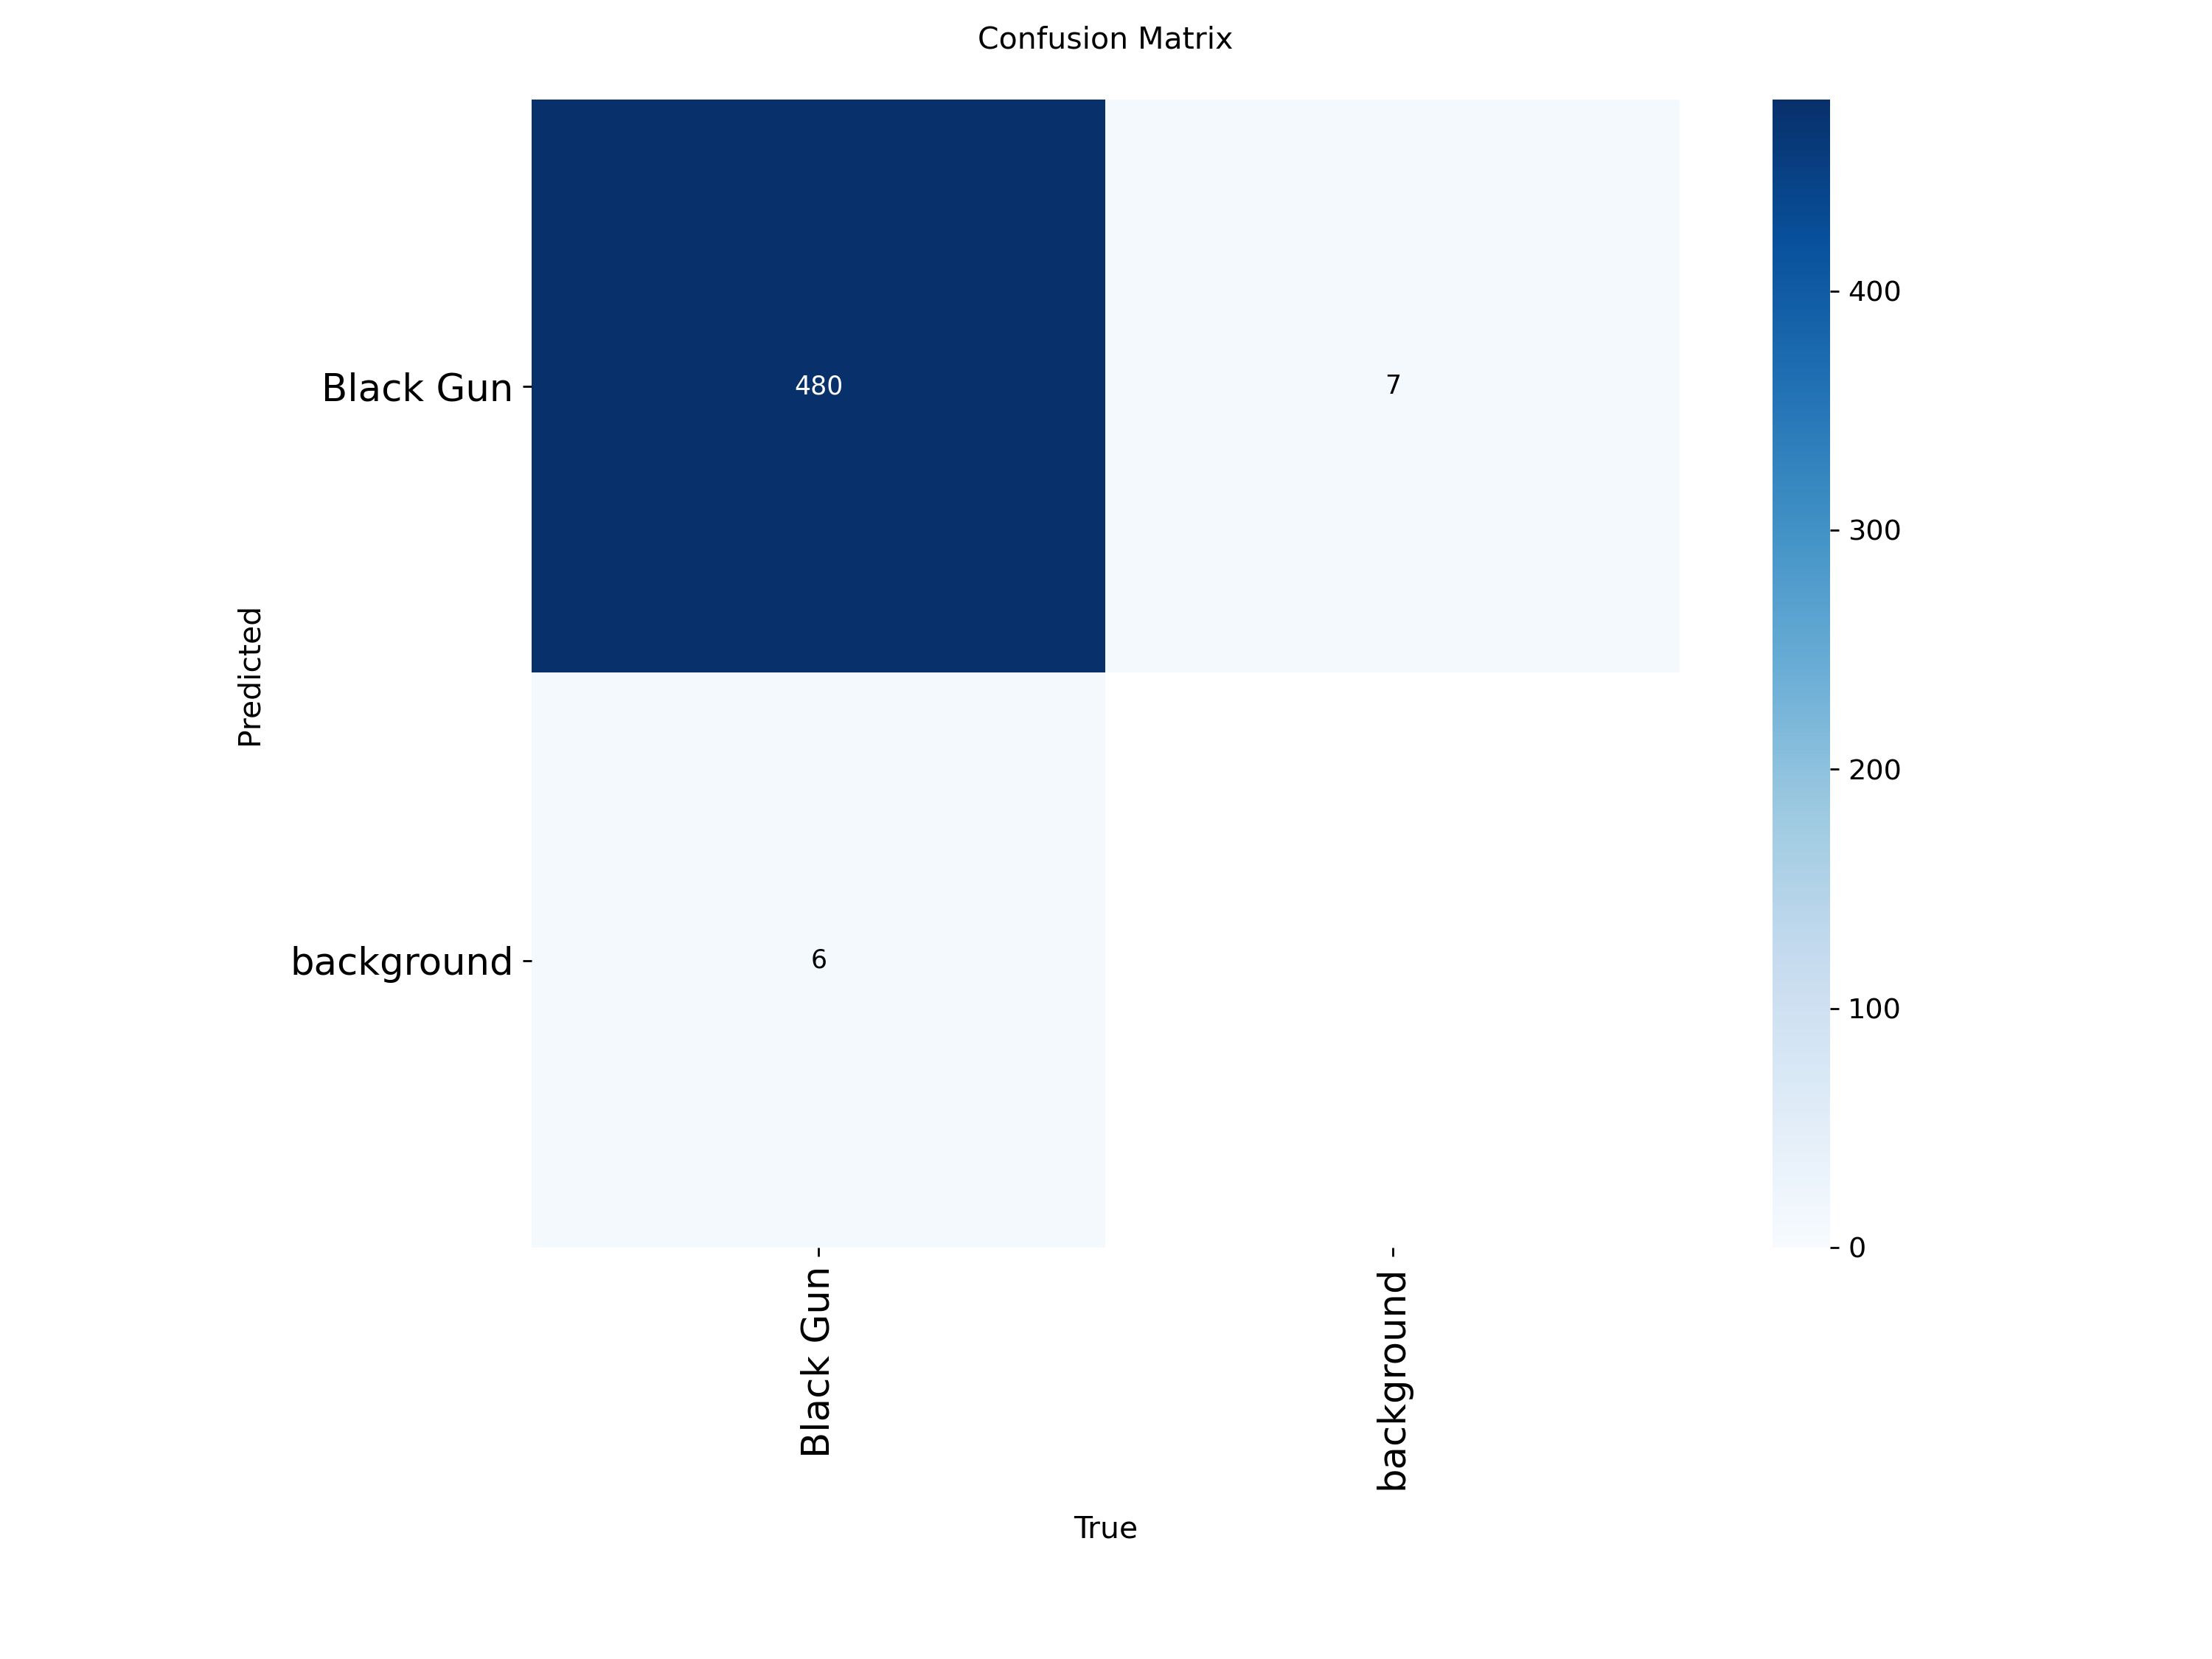


Evaluating Run: gun_detection_run_syn_v2 (6e83b006979b4033948822646f9901ea)
Model Weights: d:\_pribadi\gun_detection\mlruns\6e83b006979b4033948822646f9901ea\artifacts\weights\best.pt
Data Config: data/data_syn_v2.yaml

Ultralytics 8.4.12  Python-3.10.11 torch-2.10.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 803.9444.5 MB/s, size: 303.4 KB)
val: Scanning D:\_pribadi\gun_detection\data\labels\test.cache... 481 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 481/481  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 31/31 9.1it/s 3.4s<0.1s
                   all        481        486      0.789        0.5       0.58      0.265
Speed: 1.3ms preprocess, 2.1ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to D:\_pribadi\gun_detection\runs\test\gun_detection_run

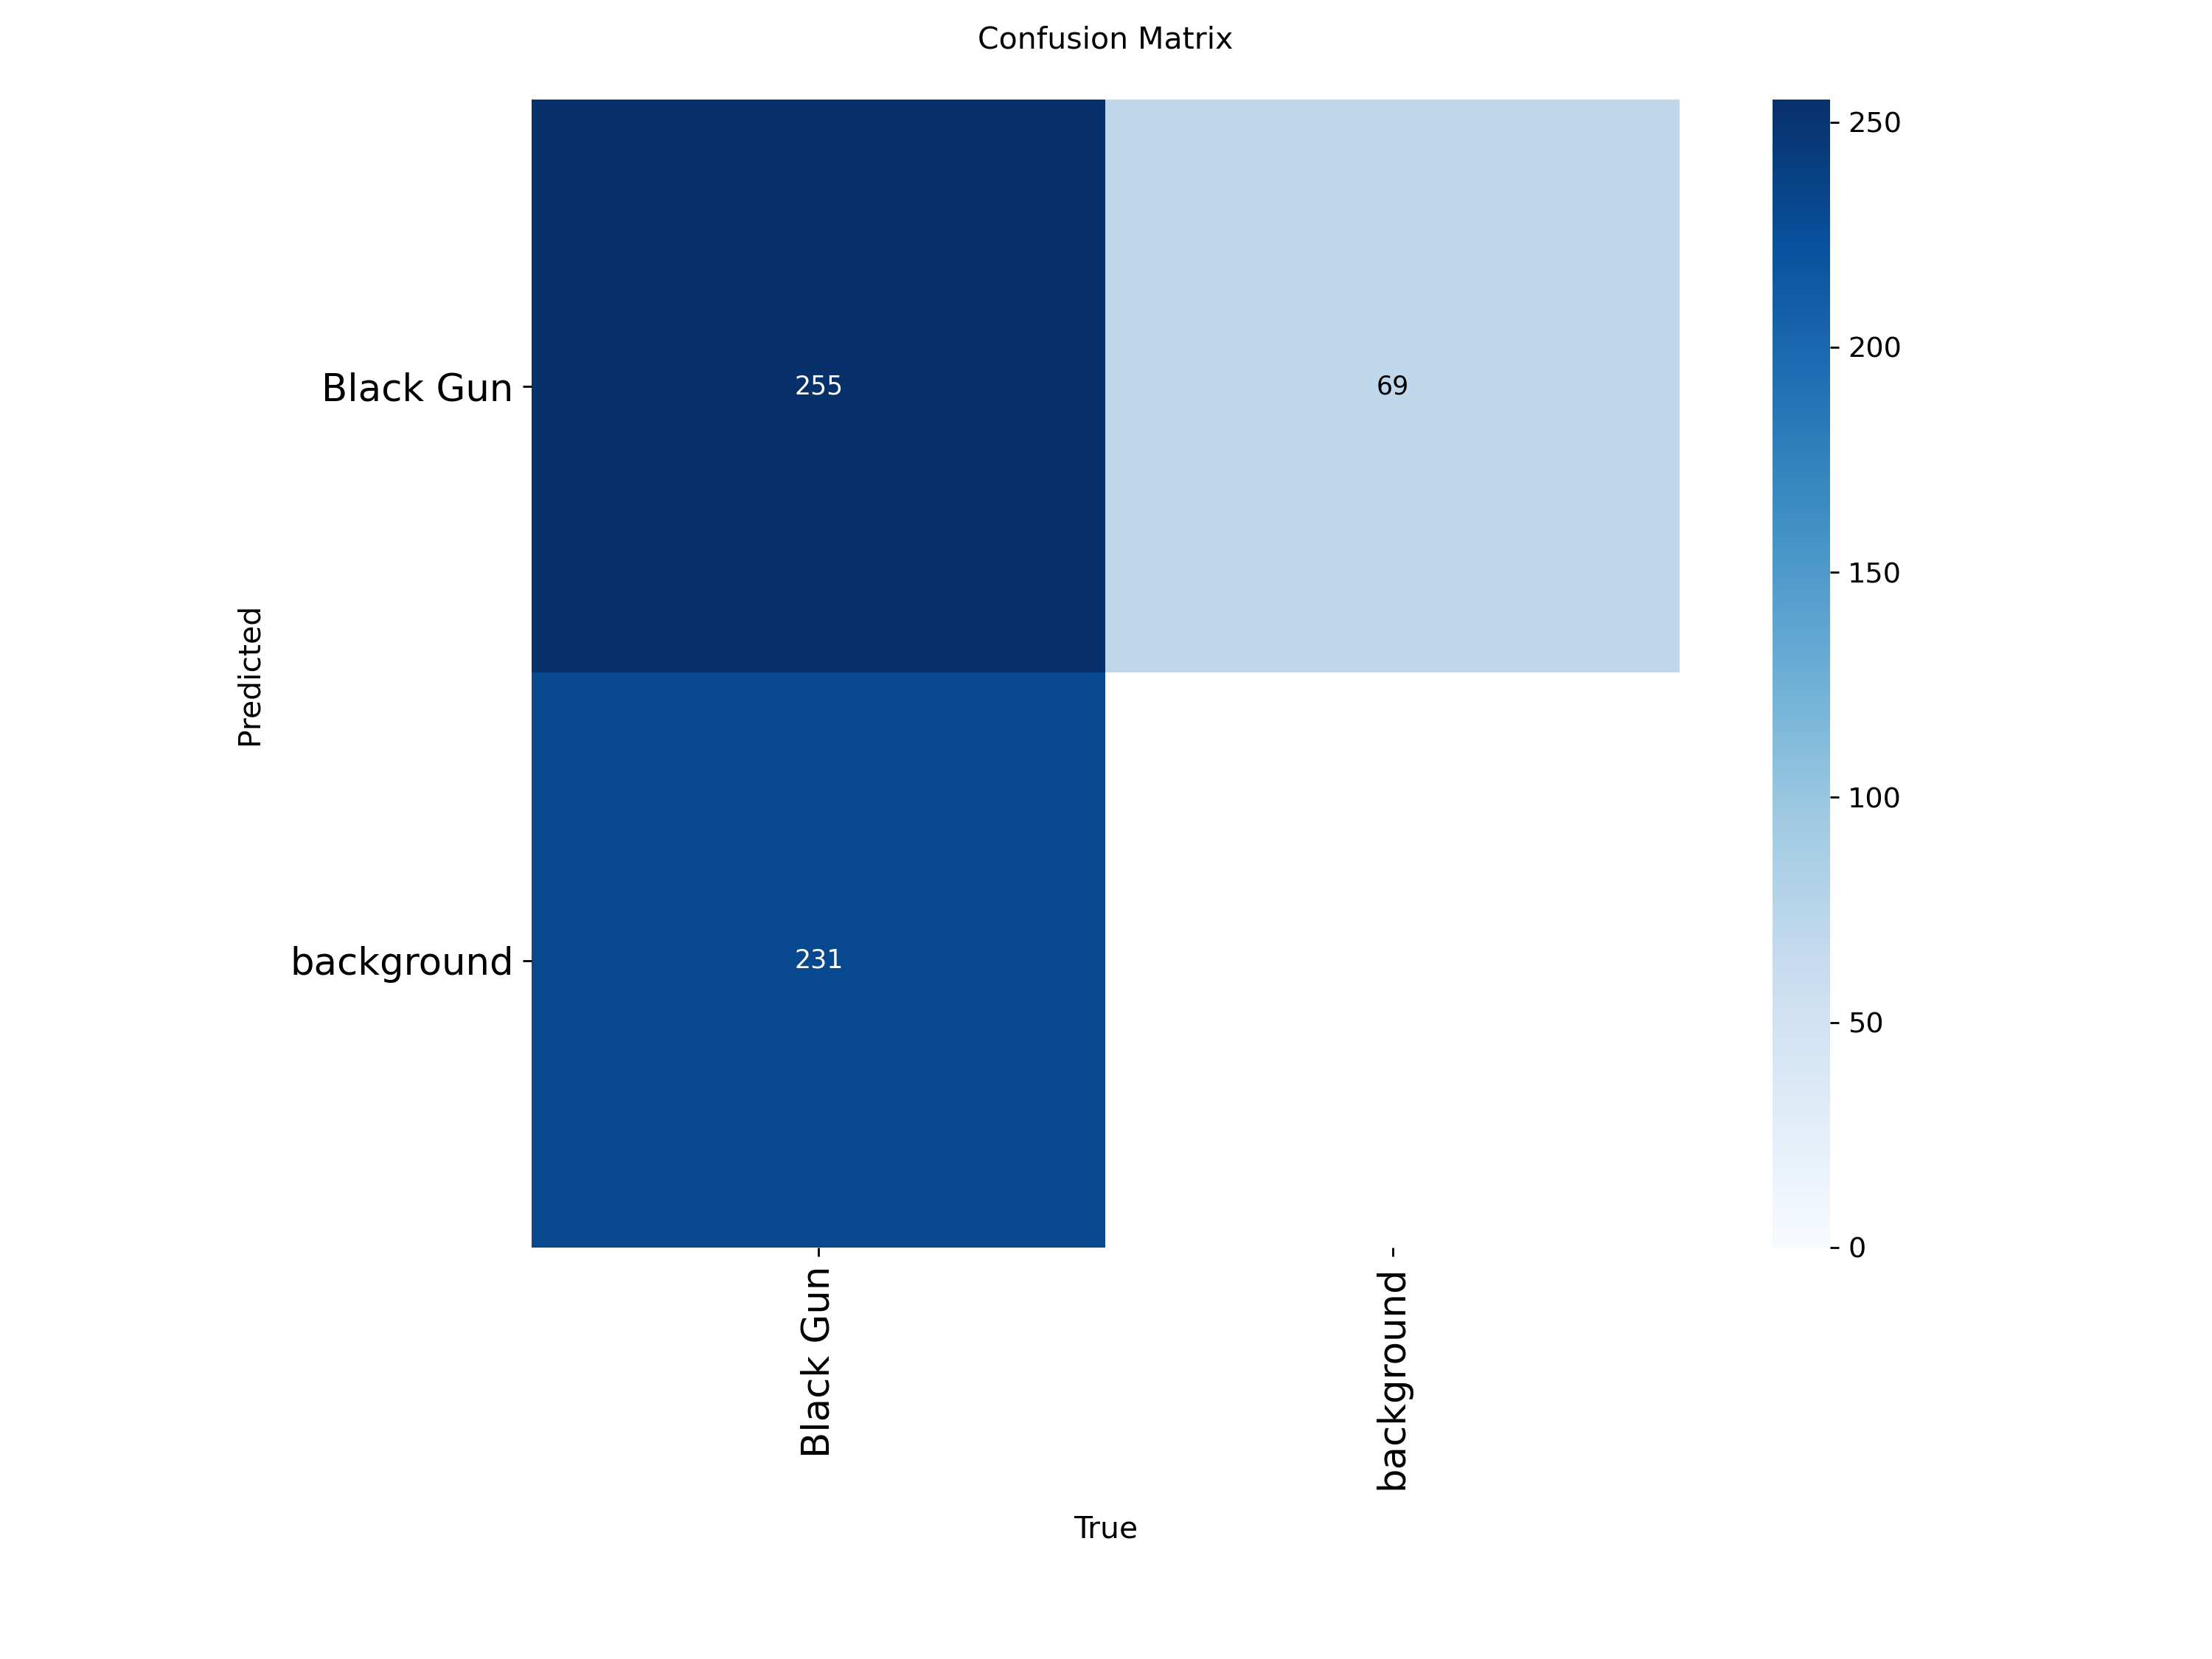


Evaluating Run: gun_detection_run_real (3c9276e87d984ecfa08832c03b87408e)
Model Weights: d:\_pribadi\gun_detection\mlruns\3c9276e87d984ecfa08832c03b87408e\artifacts\weights\best.pt
Data Config: data/data_real.yaml

Ultralytics 8.4.12  Python-3.10.11 torch-2.10.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 2009.3555.9 MB/s, size: 943.9 KB)
val: Scanning D:\_pribadi\gun_detection\data\labels\test.cache... 481 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 481/481  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 31/31 8.5it/s 3.6s0.1ss
                   all        481        486      0.954      0.877      0.941      0.633
Speed: 1.1ms preprocess, 2.2ms inference, 0.0ms loss, 0.5ms postprocess per image
Results saved to D:\_pribadi\gun_detection\runs\test\gun_detection_run_re

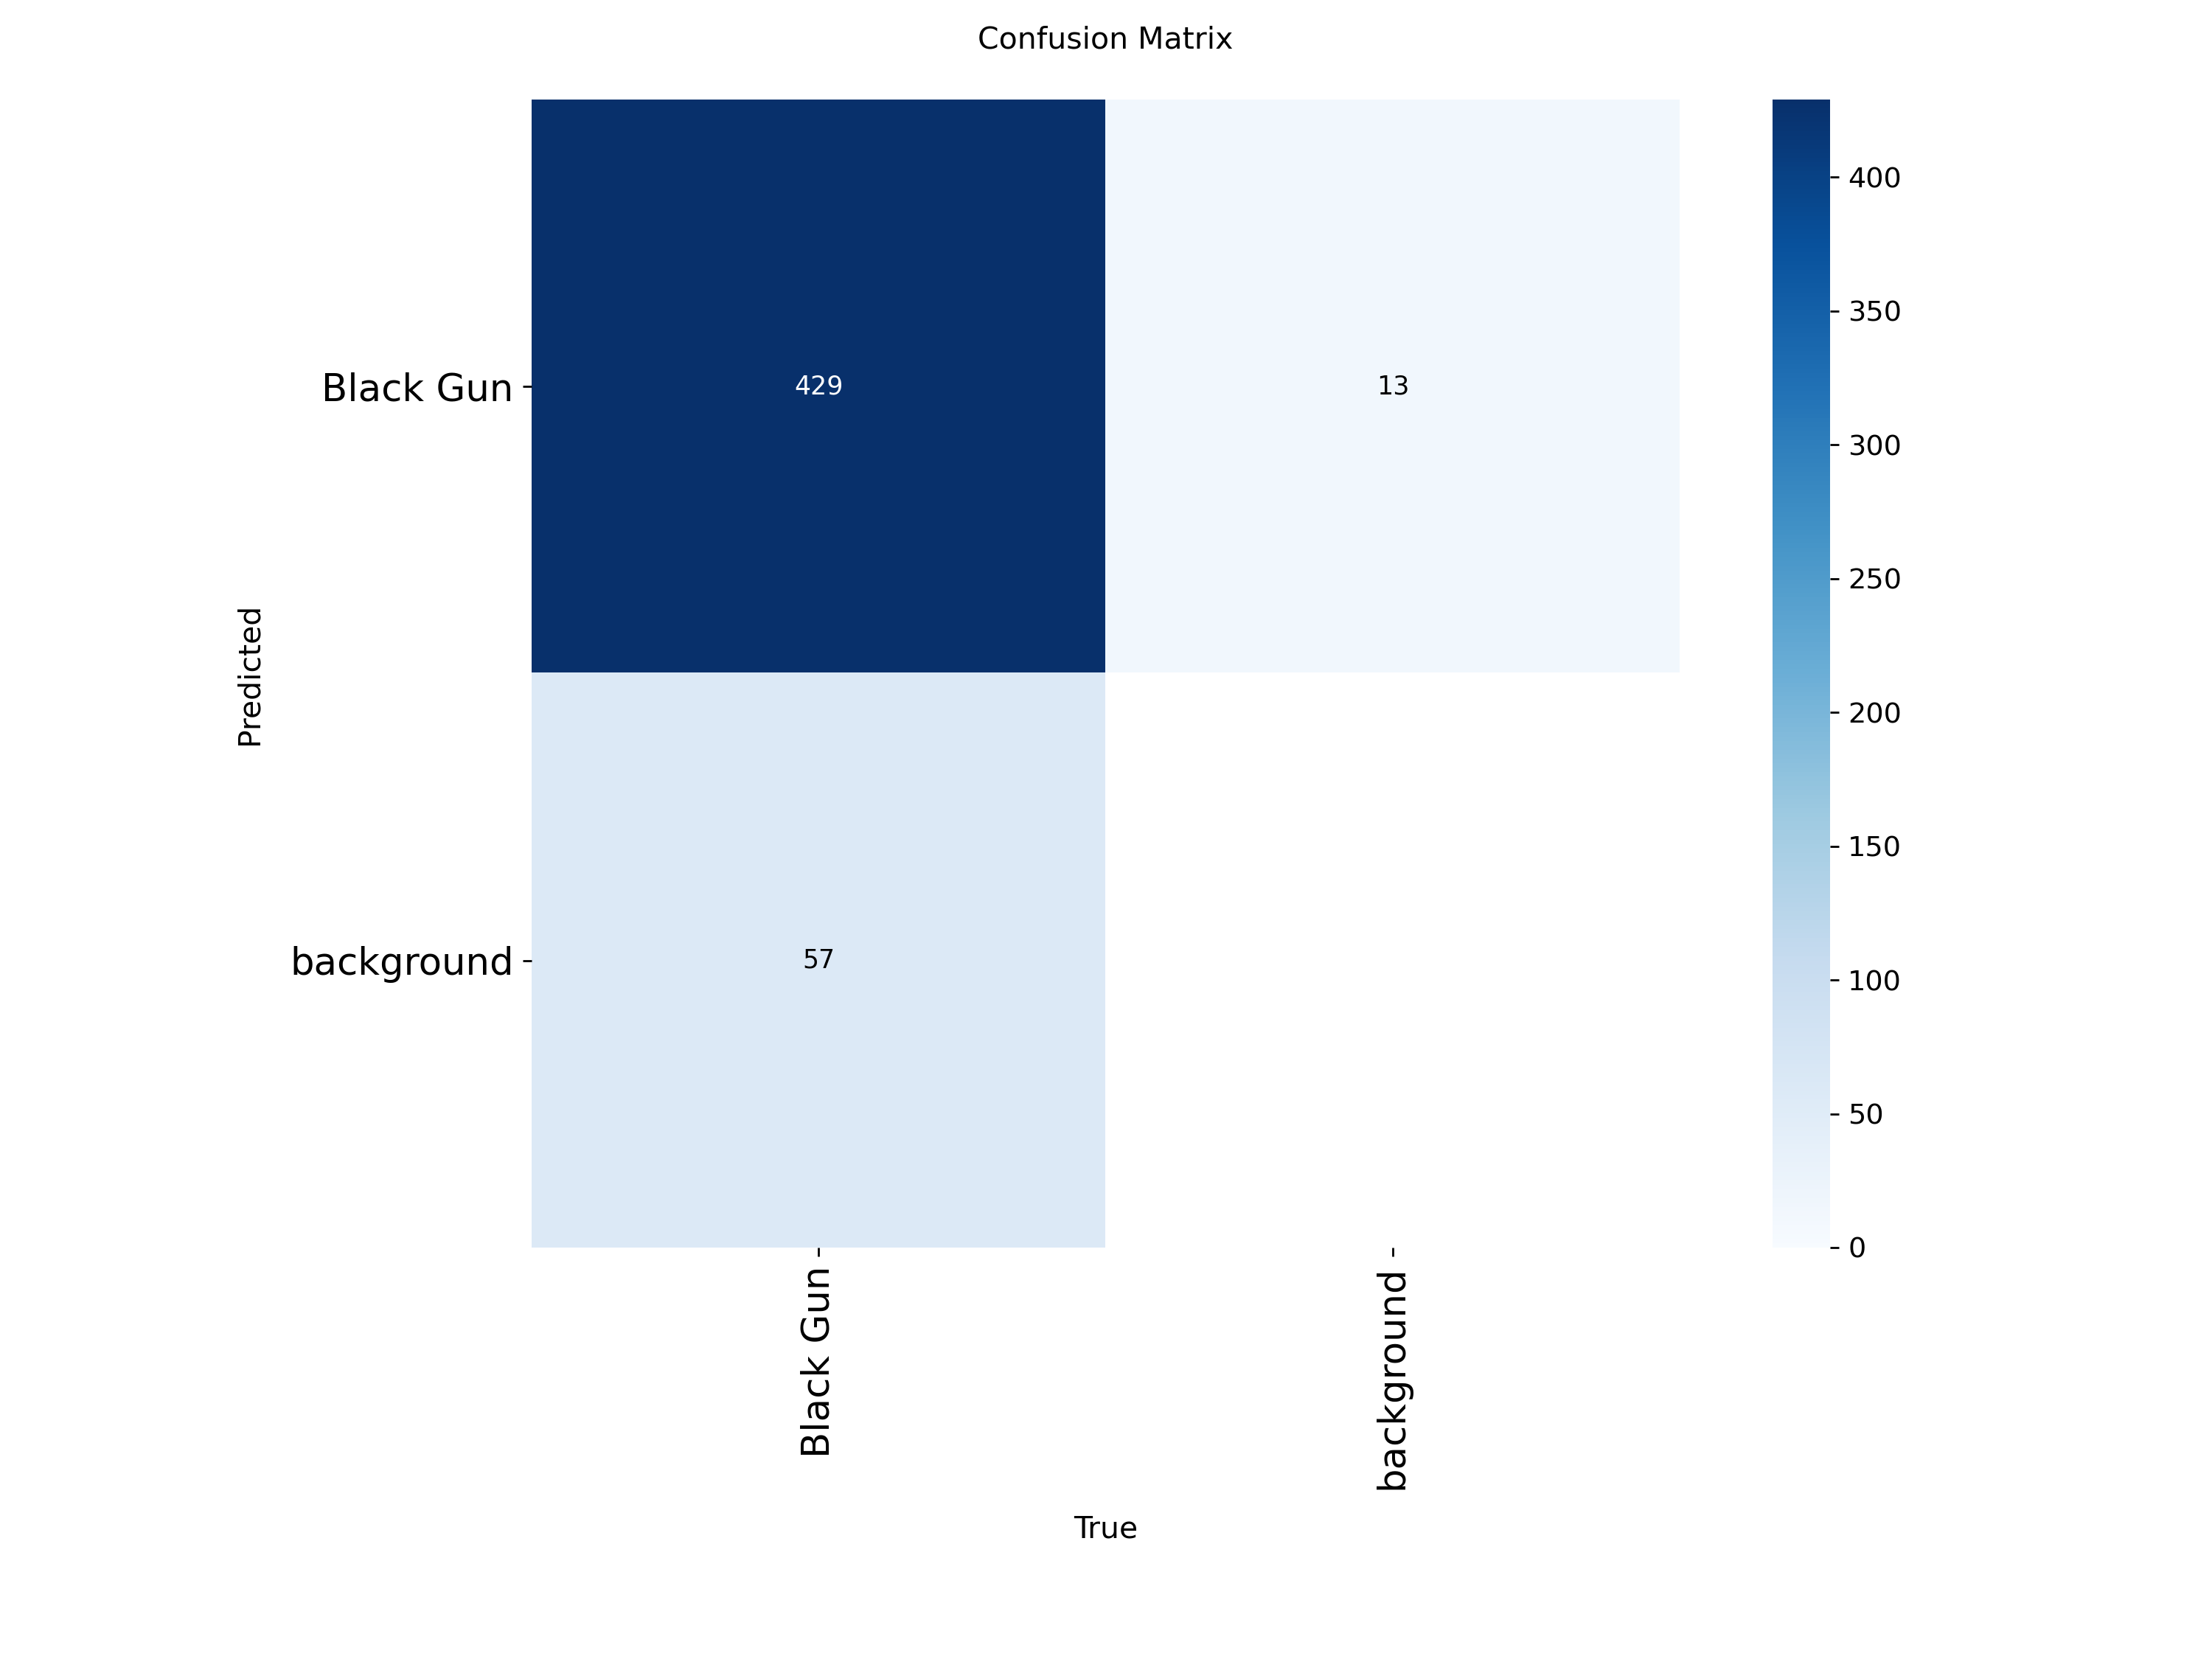

In [5]:
# --- Evaluation Loop ---

for run_info in evaluated_runs:
    print(f"\n{'='*50}")
    print(f"Evaluating Run: {run_info['run_name']} ({run_info['run_id']})")
    print(f"Model Weights: {run_info['weights']}")
    print(f"Data Config: {run_info['data']}")
    print(f"{'='*50}\n")
    
    # Load Model
    try:
        project_path = f"runs/test/{run_info['run_name']}_universal_ground_truth"
        os.makedirs(project_path, exist_ok=True)
        model = YOLO(run_info['weights'])
        
        # Evaluate on Test Split
        # The 'data' config contains the 'test' path which is used as ground truth
        metrics = model.val(
            data='data/data.yaml',
            split='test',
            device='cuda:0' if torch.cuda.is_available() else 'cpu',
            project=os.path.abspath("runs/test"),
            name=f"{run_info['run_name']}_universal_ground_truth",
            exist_ok=True,
            plots=True
        )
        
        # Display Metrics
        print(f"\nResults for {run_info['run_name']}:")
        print(f"mAP50: {metrics.box.map50:.4f}")
        print(f"mAP50-95: {metrics.box.map:.4f}")
        
        # Display Confusion Matrix
        # YOLO saves it in the project/name directory
        save_dir = metrics.save_dir
        cm_path = os.path.join(save_dir, "confusion_matrix.png")
        
        if os.path.exists(cm_path):
            print("Confusion Matrix:")
            display(Image(filename=cm_path))
        else:
            # Fallback check for normalized CM
            cm_norm_path = os.path.join(save_dir, "confusion_matrix_normalized.png")
            if os.path.exists(cm_norm_path):
                 print("Normalized Confusion Matrix:")
                 display(Image(filename=cm_norm_path))
            else:
                print("Confusion Matrix not found in output directory.")

    except Exception as e:
        print(f"Error evaluating run {run_info['run_id']}: {e}")